# The Gap as Scatterer
## Physical basis of the scattering analogy: where the analogy is exact, where it is structural, and why the instinct is correct

*Companion to the Phantom Eigenmode paper (v8) · April 2026*

---

## 1. The Claim Under Examination

The observation that launched the phantom eigenmode paper was a physical instinct: a measurement gap acts like an obstacle. The hole in the measurement creates features in the data that are not physically present, and those features are concentrated near the hole, just as a scattered field from a physical obstacle is concentrated near it.

This document examines whether that analogy is formally justified. The answer has three layers: one part is **exactly true** (not analogy at all), one part is **structurally parallel** (same mathematical architecture, different specific operator), and one part is a **genuine physical insight** about why the two problems share qualitative behavior. The boundary between these layers matters because it determines what can be proved as a theorem and what remains a useful heuristic.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv, jn_zeros
from matplotlib.gridspec import GridSpec

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f6',
    'grid.color': 'white',
    'grid.linewidth': 1.2,
})


---
## Physical motivation: what scattering from an obstacle looks like

Before the mathematics, a picture. When a 2D wave encounters a circular obstacle, it creates a **scattered field** radiating away from the obstacle — strongest near the boundary, with spatial amplitude falling off at distance (physical scattering satisfies the Sommerfeld radiation condition), and with interference fringes at the wave's spatial frequency. The gap in a measurement domain creates a structurally analogous object in the analysis domain (though with global oscillatory sidelobes rather than a clean far-field decay). Both figures are shown below.


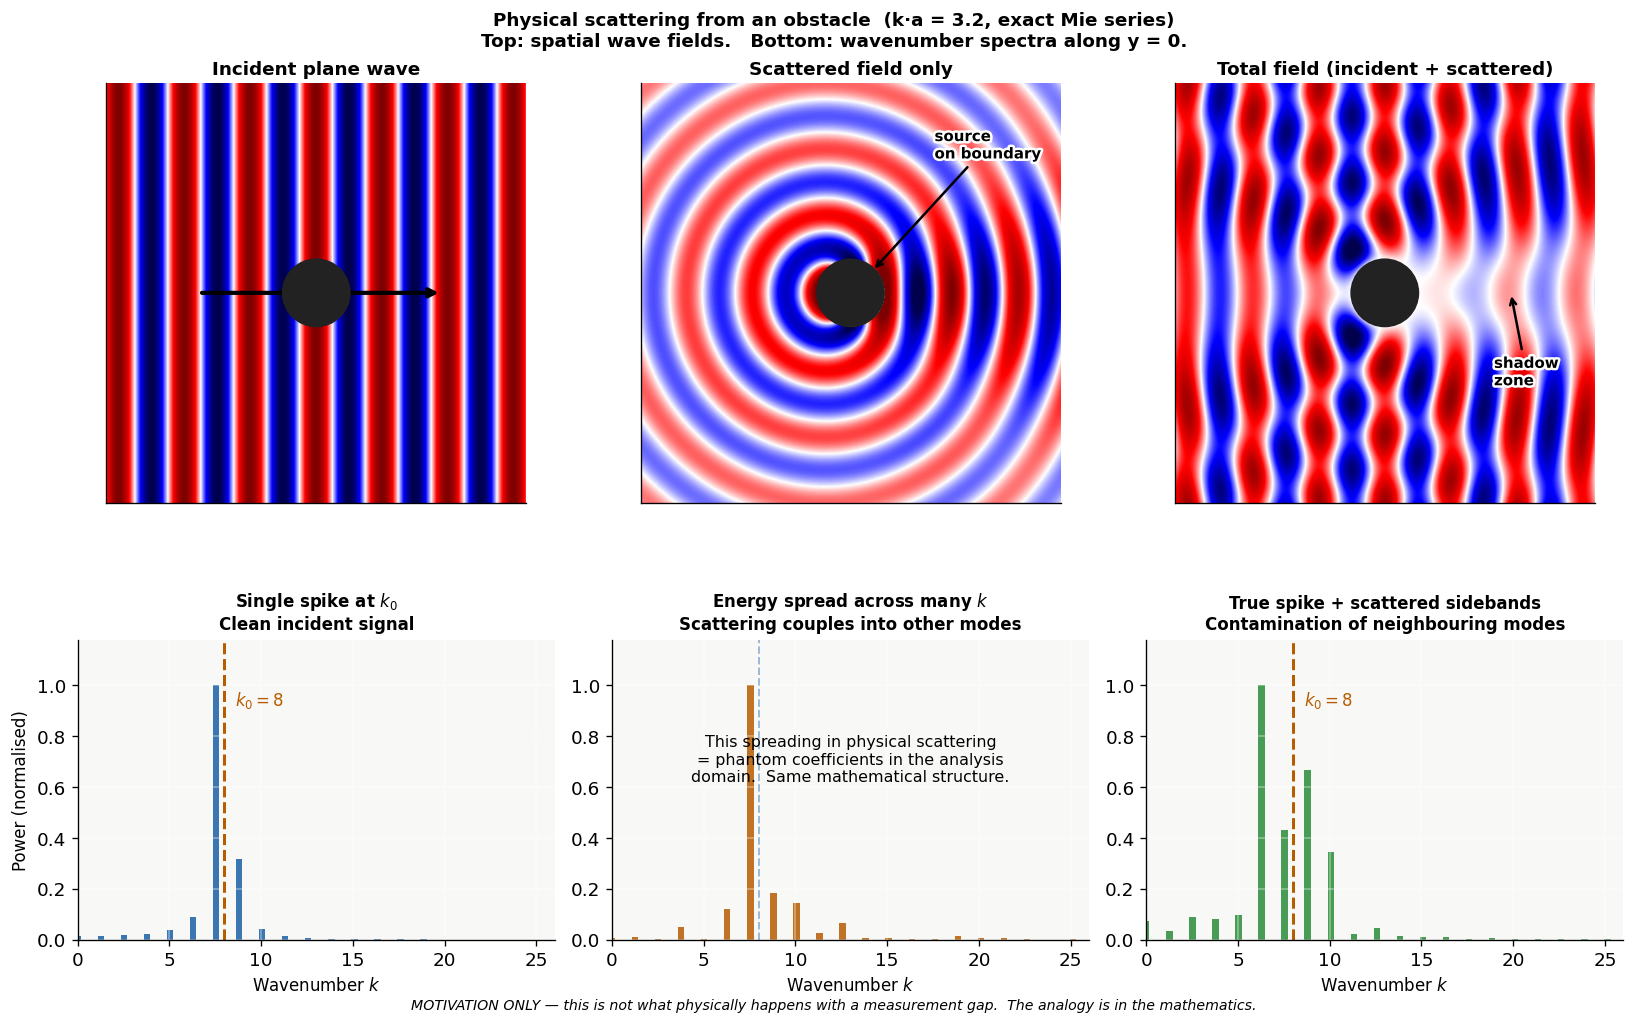

In [2]:
import matplotlib.patheffects as pe
# 2D wave scattering — physical motivation, 2-row layout
# Row 1: spatial wave fields  |  Row 2: wavenumber spectra (slice at y=0)
from scipy.special import jv, hankel1

k_wave = 8.0;  a_cyl = 0.4;  N_terms = 25
Ngrid = 500;   lim = 2.5

xg = np.linspace(-lim, lim, Ngrid)
yg = np.linspace(-lim, lim, Ngrid)
Xg, Yg = np.meshgrid(xg, yg)
Rg  = np.sqrt(Xg**2 + Yg**2)
Thg = np.arctan2(Yg, Xg)
outside = Rg > a_cyl

u_inc  = np.exp(1j * k_wave * Xg)
u_scat = np.zeros((Ngrid, Ngrid), dtype=complex)
for n in range(-N_terms, N_terms+1):
    c = -(1j)**n * jv(n, k_wave*a_cyl) / hankel1(n, k_wave*a_cyl)
    u_scat += c * hankel1(n, k_wave*Rg) * np.exp(1j*n*Thg)
u_scat[~outside] = np.nan
u_total = u_inc + u_scat;  u_total[~outside] = np.nan

mid = Ngrid // 2
def pspec(row, klim=26):
    row = np.nan_to_num(row)
    p = np.abs(np.fft.rfft(row))**2
    f = np.fft.rfftfreq(len(row), d=2*lim/len(row)) * 2*np.pi
    m = f <= klim;  p = p[m]
    return f[m], p/p.max() if p.max() > 0 else p

fi, Pi = pspec(u_inc[mid].real)
fs, Ps = pspec(u_scat[mid].real)
ft, Pt = pspec(u_total[mid].real)

fig, axes = plt.subplots(2, 3, figsize=(14, 8.5),
                         gridspec_kw=dict(height_ratios=[1.4, 1],
                                          hspace=0.38, wspace=0.12))
fig.subplots_adjust(left=0.05, right=0.97, top=0.91, bottom=0.07)

cw = 'seismic'
vt = np.nanmax(np.abs(u_total.real)) * 0.9
vs = np.nanmax(np.abs(u_scat.real))  * 0.9

def add_obs(ax):
    ax.add_patch(plt.Circle((0,0), a_cyl, color='#222', zorder=5))
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])

# --- Row 1: wave fields ---
axes[0,0].imshow(u_inc.real, cmap=cw, vmin=-1, vmax=1,
                 origin='lower', extent=[-lim,lim,-lim,lim])
add_obs(axes[0,0])
axes[0,0].set_title('Incident plane wave', fontsize=11, fontweight='bold', pad=5)
axes[0,0].annotate('', xy=(0.80,0.50), xytext=(0.22,0.50), xycoords='axes fraction',
                   arrowprops=dict(arrowstyle='->', color='black', lw=2.5))

axes[0,1].imshow(u_scat.real, cmap=cw, vmin=-vs, vmax=vs,
                 origin='lower', extent=[-lim,lim,-lim,lim])
add_obs(axes[0,1])
axes[0,1].set_title('Scattered field only', fontsize=11, fontweight='bold', pad=5)
axes[0,1].annotate('source\non boundary', xy=(a_cyl*0.65, a_cyl*0.65),
                   xytext=(0.70, 0.82), textcoords='axes fraction',
                   fontsize=9, color='black', fontweight='bold',
              path_effects=[pe.withStroke(linewidth=3, foreground='white')],
                   arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

axes[0,2].imshow(u_total.real, cmap=cw, vmin=-vt, vmax=vt,
                 origin='lower', extent=[-lim,lim,-lim,lim])
add_obs(axes[0,2])
axes[0,2].set_title('Total field (incident + scattered)', fontsize=11, fontweight='bold', pad=5)
axes[0,2].annotate('shadow\nzone', xy=(lim*0.60, 0),
                   xytext=(0.76, 0.28), textcoords='axes fraction',
                   fontsize=9, color='black', fontweight='bold',
              path_effects=[pe.withStroke(linewidth=3, foreground='white')],
                   arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

# --- Row 2: spectra ---
bkw = dict(width=0.35, alpha=0.85)

axes[1,0].bar(fi, Pi, color='#1a5fa8', **bkw)
axes[1,0].axvline(k_wave, color='#b85c00', linewidth=1.8, linestyle='--')
axes[1,0].text(k_wave+0.6, 0.92, f'$k_0={k_wave:.0f}$', fontsize=10, color='#b85c00')
axes[1,0].set_xlabel('Wavenumber $k$', fontsize=10)
axes[1,0].set_ylabel('Power (normalised)', fontsize=10)
axes[1,0].set_title('Single spike at $k_0$\nClean incident signal', fontsize=10, fontweight='bold')
axes[1,0].set_xlim(0, 26); axes[1,0].set_ylim(0, 1.18); axes[1,0].grid(True, alpha=0.3)

axes[1,1].bar(fs, Ps, color='#b85c00', **bkw)
axes[1,1].axvline(k_wave, color='#1a5fa8', linewidth=1.2, linestyle='--', alpha=0.4)
axes[1,1].set_xlabel('Wavenumber $k$', fontsize=10)
axes[1,1].set_title('Energy spread across many $k$\nScattering couples into other modes', fontsize=10, fontweight='bold')
axes[1,1].set_xlim(0, 26); axes[1,1].set_ylim(0, 1.18); axes[1,1].grid(True, alpha=0.3)
axes[1,1].text(0.50, 0.60,
    'This spreading in physical scattering\n'
    '= phantom coefficients in the analysis\n'
    'domain.  Same mathematical structure.',
    transform=axes[1,1].transAxes, ha='center', va='center', fontsize=9.5)

axes[1,2].bar(ft, Pt, color='#2a8c3a', **bkw)
axes[1,2].axvline(k_wave, color='#b85c00', linewidth=1.8, linestyle='--')
axes[1,2].text(k_wave+0.6, 0.92, f'$k_0={k_wave:.0f}$', fontsize=10, color='#b85c00')
axes[1,2].set_xlabel('Wavenumber $k$', fontsize=10)
axes[1,2].set_title('True spike + scattered sidebands\nContamination of neighbouring modes', fontsize=10, fontweight='bold')
axes[1,2].set_xlim(0, 26); axes[1,2].set_ylim(0, 1.18); axes[1,2].grid(True, alpha=0.3)

fig.suptitle(
    f'Physical scattering from an obstacle  (k·a = {k_wave*a_cyl:.1f}, exact Mie series)\n'
    'Top: spatial wave fields.   Bottom: wavenumber spectra along y = 0.',
    fontsize=11, fontweight='bold')
fig.text(0.5, 0.002,
    'MOTIVATION ONLY — this is not what physically happens with a measurement gap.  '
    'The analogy is in the mathematics.',
    ha='center', fontsize=8.5, color='black', style='italic')
plt.show()


### The same architecture — but now the obstacle is a measurement gap

The top row is unchanged: the same physical wave fields. The bottom row shows what happens in the **analysis domain** when the "obstacle" is a measurement hole. The structure is identical — clean spike → spread → contaminated — but the mechanism is different. The following sections make the correspondence precise.


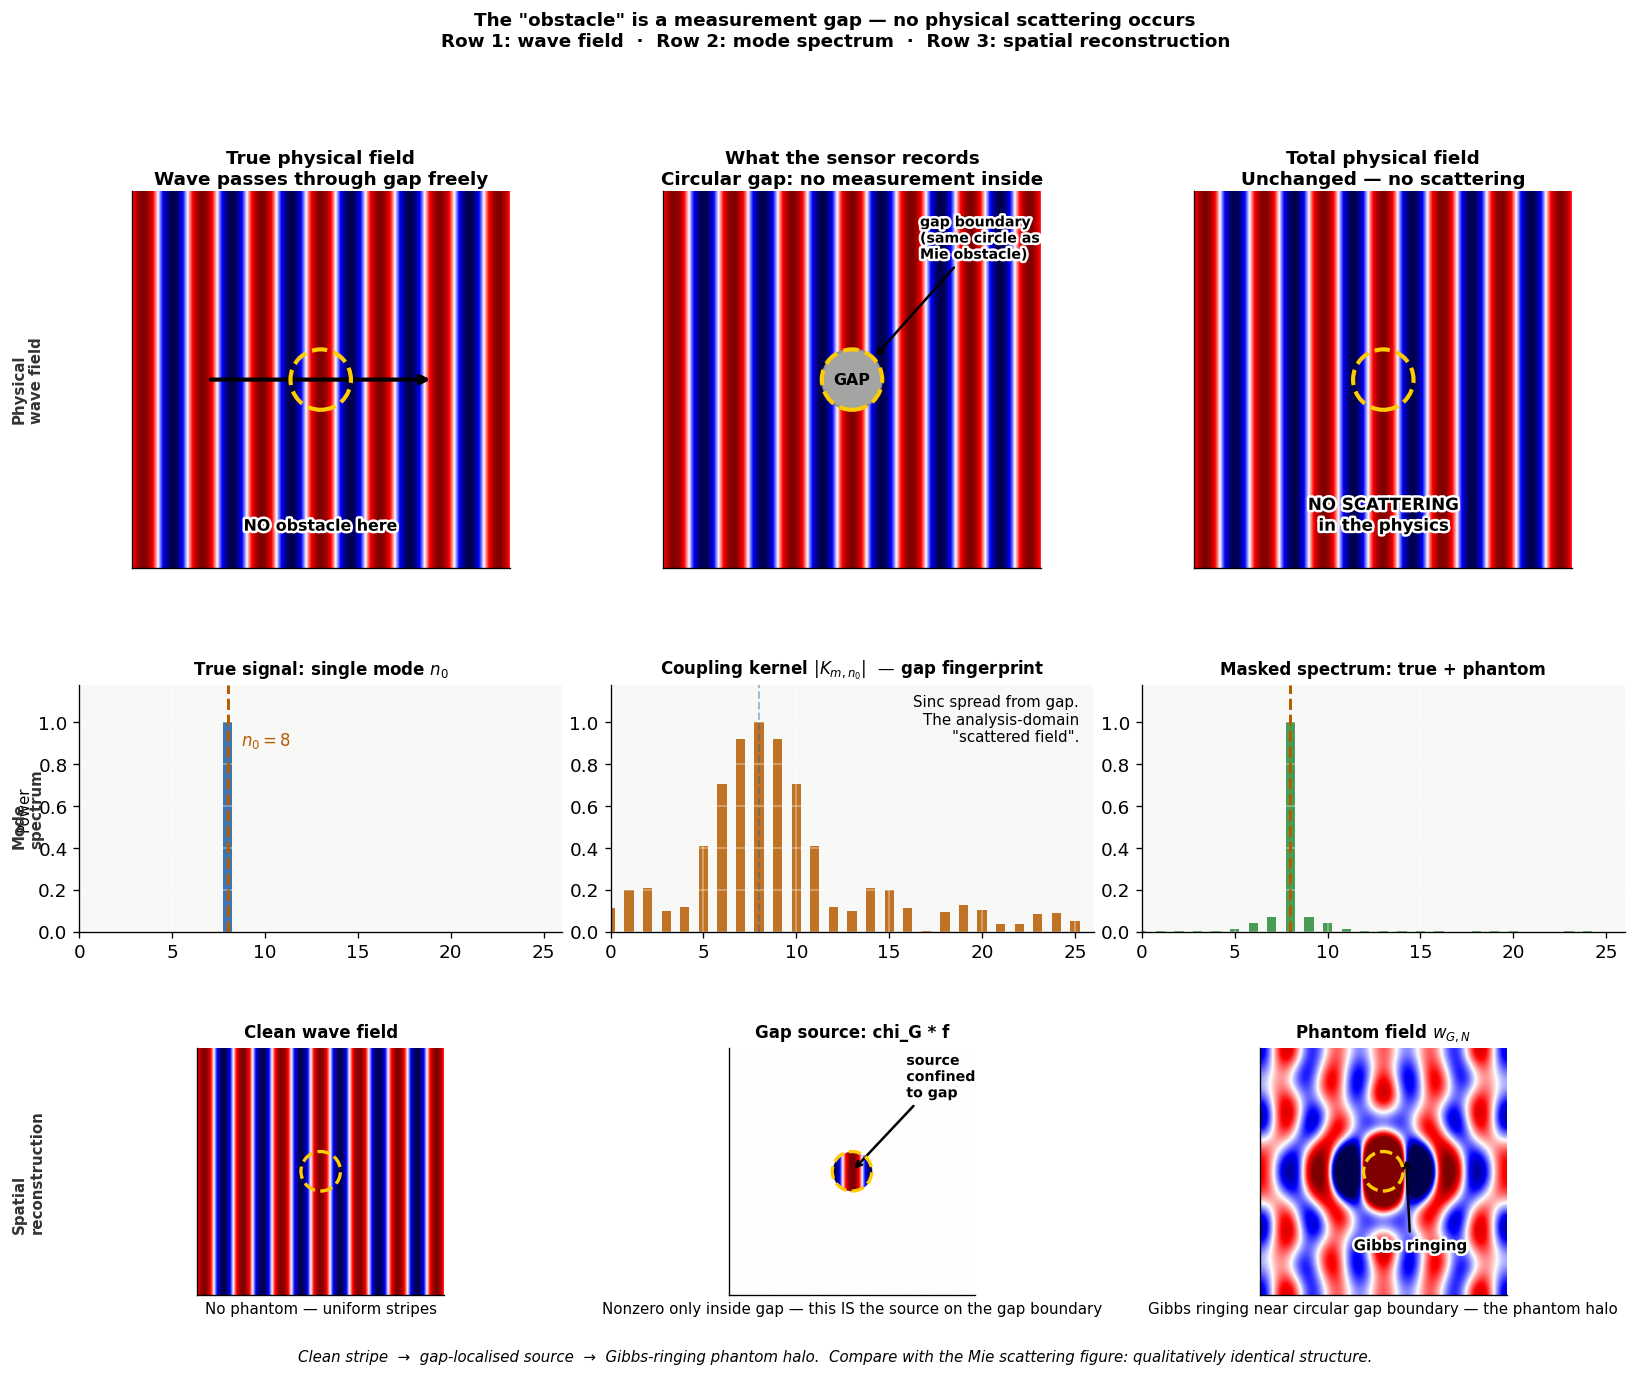

In [3]:
import matplotlib.patheffects as pe
# Companion figure: obstacle → measurement gap
# Row 1: physical wave fields (unchanged)
# Row 2: analysis-domain phantom spectra
# Row 3: IFFT spatial reconstructions — hammers home the parallel

k0_h  = int(k_wave)   # same source mode (k=8)
a_gap = 0.7           # gap half-width on periodic domain [-pi, pi]
N_h   = 25            # bandwidth

m_arr = np.arange(0, N_h+1, dtype=float)

# Coupling kernel
def Kmk(m, k0, a):
    if m == k0: return a / np.pi
    return np.sin((k0 - m)*a) / (np.pi*(k0 - m))  # signed: abs() removed (audit fix)

a_n = a_gap / np.pi  # missing mass fraction

P_true     = np.zeros(len(m_arr)); P_true[k0_h] = 1.0
P_coupling = np.array([Kmk(int(m), k0_h, a_gap) for m in m_arr])
P_coupling_norm = P_coupling / P_coupling.max()
P_masked   = np.array([(1-a_n)**2 if int(m)==k0_h else Kmk(int(m),k0_h,a_gap)**2
                       for m in m_arr])
P_masked   = P_masked / P_masked.max()

# --- Spatial reconstructions in complex-exponential basis (1D periodic domain, rendered as 2D) ---
# Basis: {e^{imx}}_{m in Z}. True mode is f(x) = e^{ik0 x}; display Re(.) on all panels.
# Matching convention used in hole_problem.ipynb §4 and §IV.
Nx = 600
x1d = np.linspace(-np.pi, np.pi, Nx, endpoint=False)
gap_mask_1d = np.abs(x1d) <= a_gap

# Reconstruction 1: true mode Re(e^{ik0 x}) = cos(k0 x)
recon_true = np.cos(k0_h * x1d)

# Reconstruction 2: coupling kernel projected back to space
# sum_{|m|<=N} K_{m,k0} * e^{imx} approximates chi_G(x) * e^{ik0 x} (gap-restricted true field)
# This is the SOURCE of the phantom — nonzero only inside the gap in the N -> infinity limit
recon_coupling_c = np.zeros(Nx, dtype=complex)
for m in range(-N_h, N_h+1):
    recon_coupling_c += Kmk(m, k0_h, a_gap) * np.exp(1j * m * x1d)
recon_coupling = recon_coupling_c.real
# Exact (N -> infty) target: chi_G * cos(k0 x)
recon_coupling_exact = np.where(gap_mask_1d, np.cos(k0_h * x1d), 0.0)

# Reconstruction 3: ONLY the off-diagonal phantom part
# = -sum_{m != k0, |m|<=N} K_{m,k0} e^{imx}; exclude the attenuated true mode for clarity
recon_masked_c = np.zeros(Nx, dtype=complex)
for m in range(-N_h, N_h+1):
    if m != k0_h:
        recon_masked_c += -Kmk(m, k0_h, a_gap) * np.exp(1j * m * x1d)
recon_masked = recon_masked_c.real

# Tile 1D fields into 2D images for visual comparison with wave panels
Ny_tile = 180
def tile_1d(field, ny=Ny_tile):
    return np.tile(field, (ny, 1))

img_true     = tile_1d(recon_true)
img_coupling = tile_1d(recon_coupling_exact)   # exact: chi_G * f (the source)
img_masked   = tile_1d(recon_masked)

# --- Figure: 3 rows x 3 cols ---
fig = plt.figure(figsize=(14, 11.5))
fig.subplots_adjust(left=0.05, right=0.97, top=0.85, bottom=0.05,
                    hspace=0.40, wspace=0.10)
gs = fig.add_gridspec(3, 3, height_ratios=[1.3, 0.85, 0.85])

cw = 'seismic'
bkw = dict(width=0.5, alpha=0.85)

def add_obs3(ax):
    ax.add_patch(plt.Circle((0,0), a_cyl, color='#222', zorder=5))
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])

# ── Row 1: NO physical scattering — gap does not affect the wave ─────────
# Gap is the SAME circular region as the Mie obstacle — same geometry, different physics
ax00 = fig.add_subplot(gs[0,0]); ax01 = fig.add_subplot(gs[0,1]); ax02 = fig.add_subplot(gs[0,2])

gap_circle = Rg <= a_cyl   # same shape/location as the Mie obstacle

def fmt_ax(ax):
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])

# Panel 1: True physical field — wave passes through the circle freely
ax00.imshow(u_inc.real, cmap=cw, vmin=-1, vmax=1, origin='lower', extent=[-lim,lim,-lim,lim])
# Draw the gap circle as a dashed outline (no fill — wave passes through)
circ_outline = plt.Circle((0,0), a_cyl, color='#ffcc00', fill=False,
                           linewidth=2.5, linestyle='--', zorder=5)
ax00.add_patch(circ_outline)
fmt_ax(ax00)
ax00.set_title('True physical field\nWave passes through gap freely', fontsize=11, fontweight='bold', pad=4)
ax00.annotate('', xy=(0.80,0.50), xytext=(0.20,0.50), xycoords='axes fraction',
              arrowprops=dict(arrowstyle='->', color='black', lw=2.5))
ax00.text(0.50, 0.10, 'NO obstacle here', transform=ax00.transAxes,
          ha='center', color='black', fontsize=9.5, fontweight='bold',
          path_effects=[pe.withStroke(linewidth=3, foreground='white')])

# Panel 2: What sensor records — wave measured outside, missing inside gap circle
u_measured = u_inc.real.copy(); u_measured[gap_circle] = np.nan
ax01.imshow(u_measured, cmap=cw, vmin=-1, vmax=1, origin='lower', extent=[-lim,lim,-lim,lim])
gap_grey = plt.Circle((0,0), a_cyl, color='#888888', alpha=0.75, zorder=4)
circ2 = plt.Circle((0,0), a_cyl, color='#ffcc00', fill=False, linewidth=2.5, linestyle='--', zorder=5)
ax01.add_patch(gap_grey); ax01.add_patch(circ2)
fmt_ax(ax01)
ax01.set_title('What the sensor records\nCircular gap: no measurement inside', fontsize=11, fontweight='bold', pad=4)
ax01.text(0, 0, 'GAP', ha='center', va='center', color='black',
          fontsize=9.5, fontweight='bold', zorder=6)
ax01.annotate('gap boundary\n(same circle as\nMie obstacle)', xy=(a_cyl*0.7, a_cyl*0.7),
              xytext=(0.68, 0.82), textcoords='axes fraction',
              fontsize=8.5, color='black', fontweight='bold',
              path_effects=[pe.withStroke(linewidth=3, foreground='white')],
              arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

# Panel 3: Total physical field — identical to incident, no scattered rings
ax02.imshow(u_inc.real, cmap=cw, vmin=-1, vmax=1, origin='lower', extent=[-lim,lim,-lim,lim])
circ3 = plt.Circle((0,0), a_cyl, color='#ffcc00', fill=False, linewidth=2.5, linestyle='--', zorder=5)
ax02.add_patch(circ3)
fmt_ax(ax02)
ax02.set_title('Total physical field\nUnchanged — no scattering', fontsize=11, fontweight='bold', pad=4)
ax02.text(0.50, 0.10, 'NO SCATTERING\nin the physics', transform=ax02.transAxes,
          ha='center', color='black', fontsize=10, fontweight='bold',
          path_effects=[pe.withStroke(linewidth=3, foreground='white')])

# ── Row 2: phantom spectra ───────────────────────────────────────────────
ax10 = fig.add_subplot(gs[1,0]); ax11 = fig.add_subplot(gs[1,1]); ax12 = fig.add_subplot(gs[1,2])

ax10.bar(m_arr, P_true, color='#1a5fa8', **bkw)
ax10.axvline(k0_h, color='#b85c00', linewidth=1.8, linestyle='--')
ax10.text(k0_h+0.7, 0.89, f'$n_0={k0_h}$', fontsize=10, color='#b85c00')
ax10.set_title('True signal: single mode $n_0$', fontsize=10, fontweight='bold')
ax10.set_ylabel('Power', fontsize=9); ax10.set_xlim(0,26); ax10.set_ylim(0,1.18); ax10.grid(True,alpha=0.3)

ax11.bar(m_arr, P_coupling_norm, color='#b85c00', **bkw)
ax11.axvline(k0_h, color='#1a5fa8', linewidth=1.2, linestyle='--', alpha=0.4)
ax11.set_title(r'Coupling kernel $|K_{m,n_0}|$  — gap fingerprint', fontsize=10, fontweight='bold')
ax11.set_xlim(0,26); ax11.set_ylim(0,1.18); ax11.grid(True,alpha=0.3)
ax11.text(0.97, 0.96, 'Sinc spread from gap.\nThe analysis-domain\n"scattered field".',
          transform=ax11.transAxes, ha='right', va='top', fontsize=9)

ax12.bar(m_arr, P_masked, color='#2a8c3a', **bkw)
ax12.axvline(k0_h, color='#b85c00', linewidth=1.8, linestyle='--')
ax12.set_title('Masked spectrum: true + phantom', fontsize=10, fontweight='bold')
ax12.set_xlim(0,26); ax12.set_ylim(0,1.18); ax12.grid(True,alpha=0.3)

# ── Row 3: 2D spatial reconstructions using circular gap geometry ─────────
# Left:   true wave (no gap effect)
# Middle: gap source field = chi_G * u_inc  (field restricted to gap circle)
# Right:  finite-bandwidth reconstruction of gap source (Gibbs ringing near boundary)

ax20 = fig.add_subplot(gs[2,0]); ax21 = fig.add_subplot(gs[2,1]); ax22 = fig.add_subplot(gs[2,2])

# --- Middle: source field = wave inside gap only ---
source_2d = np.where(gap_circle, u_inc.real, 0.0)

# --- Right: bandlimited reconstruction of source (Gibbs ringing near circle boundary) ---
F_src = np.fft.fft2(source_2d)
kx2 = np.fft.fftfreq(Ngrid, d=2*lim/Ngrid) * 2*np.pi
ky2 = np.fft.fftfreq(Ngrid, d=2*lim/Ngrid) * 2*np.pi
Kx2, Ky2 = np.meshgrid(kx2, ky2)
bw_limit = k_wave * 0.8     # aggressive bandwidth cut — makes Gibbs ringing visible
F_bw = F_src * (np.sqrt(Kx2**2 + Ky2**2) <= bw_limit)
phantom_2d = np.real(np.fft.ifft2(F_bw))

def add_gap_circle(ax, filled=False, alpha=0.5):
    if filled:
        c = plt.Circle((0,0), a_cyl, color='#888888', alpha=alpha, zorder=4)
        ax.add_patch(c)
    ring = plt.Circle((0,0), a_cyl, color='#ffcc00', fill=False,
                      linewidth=2, linestyle='--', zorder=5)
    ax.add_patch(ring)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])

vr3 = 1.0
vr_mid = np.abs(source_2d).max() * 0.95
vr_rht = np.abs(phantom_2d).max() * 0.15   # scale to make ringing visible

# Left: clean plane wave — no gap effect
ax20.imshow(u_inc.real, cmap=cw, vmin=-vr3, vmax=vr3,
            origin='lower', extent=[-lim,lim,-lim,lim])
add_gap_circle(ax20, filled=False)
ax20.set_title('Clean wave field', fontsize=10, fontweight='bold')
ax20.set_xlabel('No phantom — uniform stripes', fontsize=9, color='black')

# Middle: gap source = chi_G * f  (inside circle only)
ax21.imshow(source_2d, cmap=cw, vmin=-vr_mid, vmax=vr_mid,
            origin='lower', extent=[-lim,lim,-lim,lim])
add_gap_circle(ax21, filled=False)
ax21.set_title('Gap source: chi_G * f', fontsize=10, fontweight='bold')
ax21.set_xlabel('Nonzero only inside gap — this IS the source on the gap boundary', fontsize=9, color='black')
ax21.annotate('source\nconfined\nto gap', xy=(0, 0), xytext=(0.72, 0.80),
              textcoords='axes fraction', fontsize=8.5, color='black', fontweight='bold',
              path_effects=[pe.withStroke(linewidth=3, foreground='white')],
              arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

# Right: bandlimited reconstruction — Gibbs ringing near circular boundary
ax22.imshow(phantom_2d, cmap=cw, vmin=-vr_rht, vmax=vr_rht,
            origin='lower', extent=[-lim,lim,-lim,lim])
add_gap_circle(ax22, filled=False)
ax22.set_title(r'Phantom field $w_{G,N}$', fontsize=10, fontweight='bold')
ax22.set_xlabel('Gibbs ringing near circular gap boundary — the phantom halo', fontsize=9, color='black')
ax22.annotate('Gibbs ringing', xy=(a_cyl*1.15, 0.3),
              xytext=(0.38, 0.18), textcoords='axes fraction',
              fontsize=9, color='black', fontweight='bold',
              path_effects=[pe.withStroke(linewidth=3, foreground='white')],
              arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

# Row labels on left margin
for row, label in enumerate(['Physical\nwave field', 'Mode\nspectrum', 'Spatial\nreconstruction']):
    ax = [ax00,ax10,ax20][row]
    pos = ax.get_position()
    fig.text(0.01, (pos.y0+pos.y1)/2, label, ha='left', va='center',
             fontsize=9, fontweight='bold', color='#333', rotation=90)

fig.suptitle(
    'The "obstacle" is a measurement gap — no physical scattering occurs\n'
    'Row 1: wave field  ·  Row 2: mode spectrum  ·  Row 3: spatial reconstruction',
    fontsize=11, fontweight='bold')
fig.text(0.5, 0.002,
    'Clean stripe  →  gap-localised source  →  Gibbs-ringing phantom halo.  '
    'Compare with the Mie scattering figure: qualitatively identical structure.',
    ha='center', fontsize=9, color='black', style='italic')
plt.show()


---
## 2. What Is Exactly True

### 2.1 The Source Lives on ∂G

The commutator of the Laplacian with the mask operator is:

$$[-\Delta,\, M]u = -2\nabla M \cdot \nabla u - (\Delta M)u \tag{1}$$

where $M = I - \chi_G$. For a binary mask, $\nabla M = -\nabla\chi_G$ and $\Delta M = -\Delta\chi_G$ are distributions supported on $\partial G$, the boundary of the gap. This is not a metaphor or an approximation. It is a distributional identity that holds in the same sense as any PDE source term.

In physical scattering theory, when a wave $u$ satisfies $(-\Delta - k^2)u = 0$ in free space and encounters an obstacle $\Omega_o$ with Dirichlet boundary, the total field $u = u_{\text{inc}} + u_{\text{sc}}$ decomposes into an incident field and a scattered field. The scattered field is sourced by the boundary: formally, the Lippmann-Schwinger equation writes the scattering as an integral over $\partial\Omega_o$ of the incident field's boundary values against the Green's function.

The measurement gap creates the same source geometry. The commutator $[-\Delta, M]$ is supported on $\partial G$ and acts on the true field $u$. The "scattered field" — the phantom contribution — is sourced on exactly the same geometric locus as physical scattering from an obstacle with boundary $\partial G$. **The source location is not analogous; it is identical.**

### 2.2 The Coupling Is a Property of the Hole

The coupling matrix that creates phantom coefficients is:

$$K_{mn} = \int_G \varphi_n\,\bar{\varphi}_m \tag{2}$$

This depends on $\chi_G$ and on the eigenbasis $\{\varphi_n\}$ — neither of which involves the signal. $K_{mn}$ is a property of the hole geometry and the domain's modal structure. A different signal $f = \sum_n c_n\varphi_n$ passing through the same hole produces phantom coefficients $\hat{c}_m = \sum_n A_{mn}c_n$ with the same matrix $A$, differing only in the input vector $c$. The hole has a fixed spectral fingerprint — the matrix $K$ — that gets stamped onto every signal.

This is exactly analogous to a physical scatterer. The scattering matrix (S-matrix, T-matrix) of a physical obstacle depends on the obstacle geometry and the wave operator, not on the incident field. Different incident waves scatter from the same obstacle with the same coupling structure. **The coupling is a property of the scatterer.** This part of the analogy is not just structural — the pattern "coupling determined by the scatterer geometry, not the incident field" plays the same role in both frameworks. The mathematical objects ($K_{mn}$ and the T-matrix) are different operators built from different physics; the structural principle they embody is the same.

### 2.3 The Total Energy Budget Is Exact

For a single mode $n$ with missing $L^2$-mass fraction $a_n = \int_G|\varphi_n|^2$, the total phantom energy is:

$$|c_n|^2\, a_n(1 - a_n) \tag{3}$$

This is an exact algebraic identity following from the idempotency of $M$. In physical scattering, the analogous statement is the **optical theorem**: the total scattered power is determined by the forward scattering amplitude, which in turn is determined by the obstacle's interaction cross-section with the incident wave. The quantity $a_n$ plays the role of the cross-section — it measures how much of the incident mode's energy the obstacle (gap) intercepts. The identity $a_n(1-a_n)$ is exact for the same algebraic reason that energy conservation in scattering is exact: the operator is unitary (in physical scattering) or idempotent (in the measurement gap problem), and both constraints produce quadratic identities on the coupling matrix.


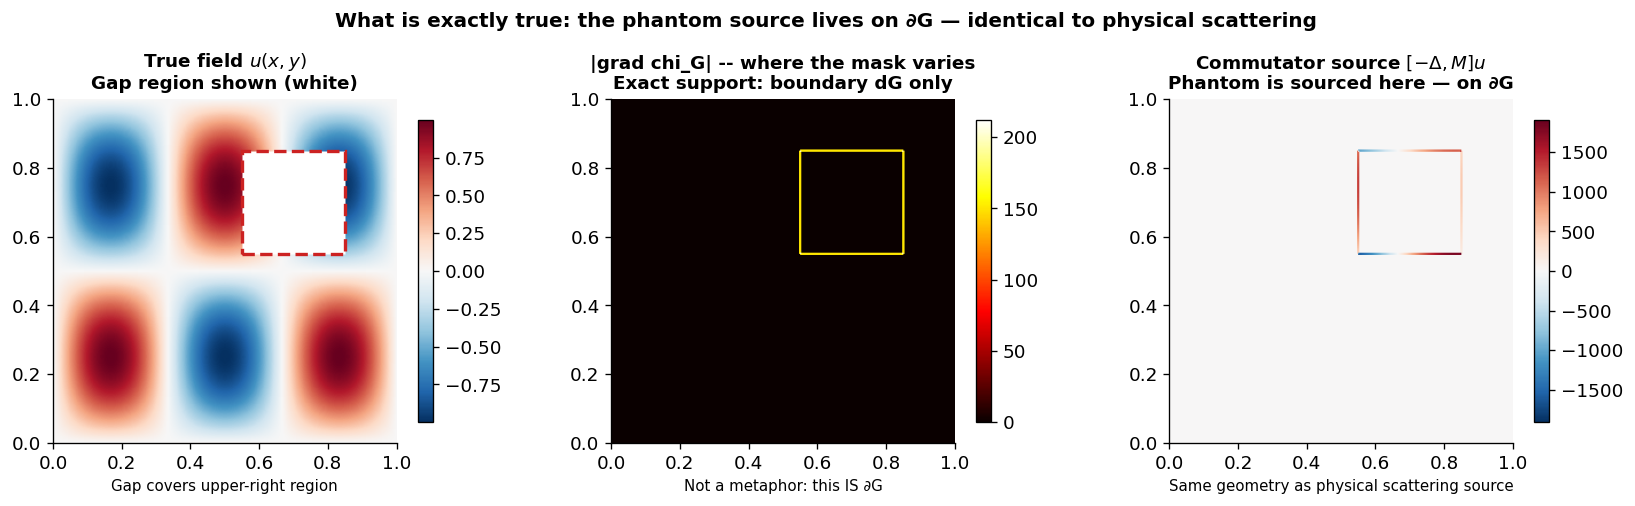

In [4]:
# --- Visualize: commutator source on ∂G ---
# Show that [-Delta, M]u is supported on the gap boundary

N = 300
x = np.linspace(0, 1, N); y = np.linspace(0, 1, N)
X, Y = np.meshgrid(x, y)

# True mode: sin(3pi x) * sin(2pi y)
u = np.sin(3*np.pi*X) * np.sin(2*np.pi*Y)

# Gap: rectangle [0.55, 0.85] x [0.55, 0.85]
x0, x1, y0, y1 = 0.55, 0.85, 0.55, 0.85
gap = ((X >= x0) & (X <= x1) & (Y >= y0) & (Y <= y1)).astype(float)

# chi_G gradient (finite differences) — supported on ∂G
def grad_fd(f, dx):
    gx = np.gradient(f, dx, axis=1)
    gy = np.gradient(f, dx, axis=0)
    return gx, gy

dx = 1.0/N
gx_chi, gy_chi = grad_fd(gap, dx)
grad_mag_chi = np.sqrt(gx_chi**2 + gy_chi**2)  # supported on ∂G

# Commutator source: -2 * grad(chi_G) . grad(u)
gx_u, gy_u = grad_fd(u, dx)
commutator_source = -2*(gx_chi*gx_u + gy_chi*gy_u)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.subplots_adjust(left=0.04, right=0.96, top=0.85, bottom=0.15, wspace=0.3)

vmax_u = np.max(np.abs(u))
im0 = axes[0].imshow(u, cmap='RdBu_r', vmin=-vmax_u, vmax=vmax_u,
                     origin='lower', extent=[0,1,0,1])
axes[0].add_patch(plt.Rectangle((x0,y0),x1-x0,y1-y0,
    fill=True, facecolor='white', edgecolor='#cc2222', linewidth=2, linestyle='--'))
axes[0].set_title('True field $u(x,y)$\nGap region shown (white)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Gap covers upper-right region', fontsize=9)
plt.colorbar(im0, ax=axes[0], shrink=0.8)

vm1 = np.max(np.abs(grad_mag_chi))
im1 = axes[1].imshow(grad_mag_chi, cmap='hot', vmin=0, vmax=vm1,
                     origin='lower', extent=[0,1,0,1])
axes[1].set_title('|grad chi_G| -- where the mask varies\nExact support: boundary dG only',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Not a metaphor: this IS ∂G', fontsize=9, color='black')
plt.colorbar(im1, ax=axes[1], shrink=0.8)

vmax_c = np.max(np.abs(commutator_source))
im2 = axes[2].imshow(commutator_source, cmap='RdBu_r', vmin=-vmax_c, vmax=vmax_c,
                     origin='lower', extent=[0,1,0,1])
axes[2].set_title(r'Leading commutator term: $+2\,\nabla\chi_G\cdot\nabla u$' + '\nSupport = ∂G (full $[-\Delta,M]u$ adds a $(\Delta\chi_G)u$ spike)',
                  fontsize=11, fontweight='bold')
axes[2].set_xlabel('Same geometry as physical scattering source', fontsize=9)
plt.colorbar(im2, ax=axes[2], shrink=0.8)

fig.suptitle('What is exactly true: the phantom source lives on ∂G — identical to physical scattering',
             fontsize=12, fontweight='bold')
plt.show()


---
## 3. What Is Structurally Parallel

### 3.1 Two Kernels, Same Eigenbasis

For structural comparison we use the static resolvent (inverse Laplacian) on a bounded domain $\Omega$ with Laplacian eigenbasis $\{\varphi_n\}$ and eigenvalues $\{\lambda_n\}$. This is the Green's function of $-\Delta u = f$, not the time-harmonic scattering resolvent $(−\Delta − k^2)^{-1}$ — see the note below for the distinction. The response kernel is:

$$G(x, y) = \sum_n \frac{\varphi_n(x)\,\bar{\varphi}_n(y)}{\lambda_n} \tag{4}$$

Each eigenfunction contributes to the response, weighted by $1/\lambda_n$. High eigenvalues (short wavelengths) are suppressed. The scattered field falls off with distance from the source: the static resolvent $(-\Delta)^{-1}$ behaves as $1/(4\pi|x-y|)$ in 3D, and the $1/\lambda_n$ spectral weighting further suppresses the short-wavelength contributions that would be needed for a sharp peak far from the source.

In the analysis-domain "scattering," the phantom field at $x$ due to the gap (here approximated by its centroid $x_G$) is mediated by the **reproducing kernel** of the finite basis. *(Note: $x_G$ is shorthand for the gap centroid; the exact source lives on $\partial G$, not at a point — see \S2.1. The point-centered picture is the small-gap leading term.)*

$$K_N(x, x_G) = \sum_{m\leq N} \varphi_m(x)\,\bar{\varphi}_m(x_G) \tag{5}$$

Each eigenfunction contributes, weighted uniformly — flat spectrum, hard cutoff at mode $N$. There is no $1/\lambda_n$ attenuation. The phantom field has its main lobe concentrated near $x_G$ on a scale $\sim 1/\sqrt{\lambda_N}$, but global oscillatory sidelobes persist at all distances — there is no monotone decay. The main-lobe concentration reflects the finite sum's inability to build broad constructive interference; the sidelobes are the Gibbs oscillations of a hard spectral cutoff.

The two kernels are built from the same eigenfunctions. They differ only in spectral weighting:

$$G(x,y):\quad \text{weight } 1/\lambda_n \text{ (smooth, power-law spatial decay)} \tag{6}$$
$$K_N(x,y):\quad \text{weight } 1 \text{ for } m\leq N,\ 0 \text{ otherwise (oscillatory, global sidelobes — no monotone decay)} \tag{7}$$

Both produce response functions that (a) peak at $y$, (b) concentrate their main lobe near $y$ (with oscillatory sidelobes persisting globally), (c) oscillate at the eigenfunction wavelengths, and (d) have spatial structure determined by the domain geometry. The quantitative decay rates differ — the Green's function falls off as a power law in $|x-y|$, while the reproducing kernel decays as an oscillatory envelope whose width scales with the cutoff $1/\sqrt{\lambda_N}$ — but the qualitative spatial behavior is shared.

### 3.2 The Structural Parallel

Both physical scattering and analysis-domain scattering share the same architecture:

**Source:** Localized on a boundary. Physical: the obstacle surface $\partial\Omega_o$. Analysis: the gap boundary $\partial G$. In both cases, the source is supported on a codimension-1 surface in the domain.

**Coupling:** A linear operator encoding the geometry. Physical: the T-matrix or S-matrix of the obstacle. Analysis: the coupling matrix $K_{mn} = \int_G \varphi_n\bar{\varphi}_m$. Both are properties of the scatterer/gap, independent of the incident signal.

**Response kernel:** An eigenfunction expansion mediating the spatial propagation. Physical: the Green's function $G(x,y)$ with $1/\lambda_n$ weighting. Analysis: the reproducing kernel $K_N(x,y)$ with uniform weighting and hard cutoff.

**Main-lobe concentration:** Both response kernels are concentrated near the source, producing a spatial pattern that is strongest close to the boundary. The concentration differs quantitatively — the Green’s function decays smoothly as a power law while the reproducing kernel has a sharp main lobe of width $\sim 1/\sqrt{\lambda_N}$ with oscillatory sinc-like sidelobes that persist globally. Neither kernel decays monotonically; both have oscillatory structure. The shared property is main-lobe localization near the source, not monotone radial falloff.

**Quadratic energy identity:** Both obey exact quadratic identities on the total scattered/phantom energy. Physical: the optical theorem. Analysis: the identity $a_n(1-a_n)$. Both follow from algebraic properties of the coupling operator (unitarity for physical scattering, idempotency for the mask). This is a shared *algebraic* structure — the *physical interpretation* of what that energy represents is different in the two cases, and is addressed in §3.3.

This is not a superficial analogy. It is structural isomorphism at the level of: source geometry, coupling operator, response kernel, and the *algebraic form* of the energy identity. The physical meaning of the "energy" differs — see §3.3 — so this is structural isomorphism at the operator level, not at the level of physical energetics. The two problems differ in the specific kernel — Green's function vs. reproducing kernel — and hence in spatial behavior: G decays with power-law falloff, while $K_N$ has a concentrated main lobe with persistent global sidelobes. The shared structure is the eigenbasis and the source architecture, not the decay profile.

### 3.3 What Is Not Parallel

The analogy breaks down in two places, and these breaks matter.

*(Correction from development record: an earlier version of this document listed a third break — "the phantom field does not satisfy a PDE." That claim was wrong. $M\varphi_n$ satisfies the forced Helmholtz equation $(-\Delta - \lambda_n)(M\varphi_n) = [-\Delta, M]\varphi_n$, with source on $\partial G$. The phantom field is a solution to a boundary-value problem — one driven by the commutator source. This is not a break in the analogy; it is another exact parallel to physical scattering, where the scattered field satisfies the same wave equation forced by boundary interactions. The PDE claim has been removed from the breakdown list.)*

**The spectral weighting is different.** The Green's function attenuates high modes as $1/\lambda_n$, giving a smooth response with power-law spatial decay (the Green's function of $-\Delta$ behaves as $1/(4\pi r)$ in 3D). The reproducing kernel includes all retained modes equally, giving an oscillatory response with a concentrated main lobe of width $\sim 1/\sqrt{\lambda_N}$ and persistent global sidelobes — not a monotone decay law. The phantom field has Gibbs-like ringing near the gap boundary and oscillatory sidelobes at all distances, unlike a physical scattered field which has a clean far field. The spatial structure differs fundamentally — power-law decay vs. main-lobe concentration with sidelobes — even though both kernels are built from the same eigenbasis.

**The energetics are different.** A physical scattered field carries real energy. It is a genuine addition to the field at every point outside the obstacle: total energy at $x$ = incident + scattered. The phantom field carries no new physical energy. Outside the gap, the phantom contribution and the attenuated true-mode piece sum exactly to the true field $f(x)$ — so the phantom does not add; it relabels. Physical scattering *redistributes* energy: the scattered field is real and measurable at every exterior point, and the scatterer conserves total energy globally while redirecting it directionally. Analysis-domain scattering *renames* energy: real measurements of a real field are attributed to false modal causes. The boundary condition that produces the source is real (the commutator on $\partial G$). The coupling is real (the matrix $K$). The spatial pattern is real (the reproducing kernel). But the energy is not new — it is old energy wearing false labels, and it sums back to the truth at every measured point.

> **Note (audit fix):** This is the *static elliptic resolvent* $(−\Delta)^{-1}$ — i.e. the inverse Laplacian — not the time-harmonic scattering resolvent $G(x,y;k) = \sum_n \varphi_n(x)\bar{\varphi}_n(y)/(\lambda_n - k^2)$ that describes propagation at a specific frequency $k$. The structural comparison (spectral weighting $1/\lambda_n$ vs. flat) is valid regardless; the correct resolvent for time-harmonic scattering has the same eigenbasis with poles at the eigenvalues. See Colton & Kress (Ref. 4).


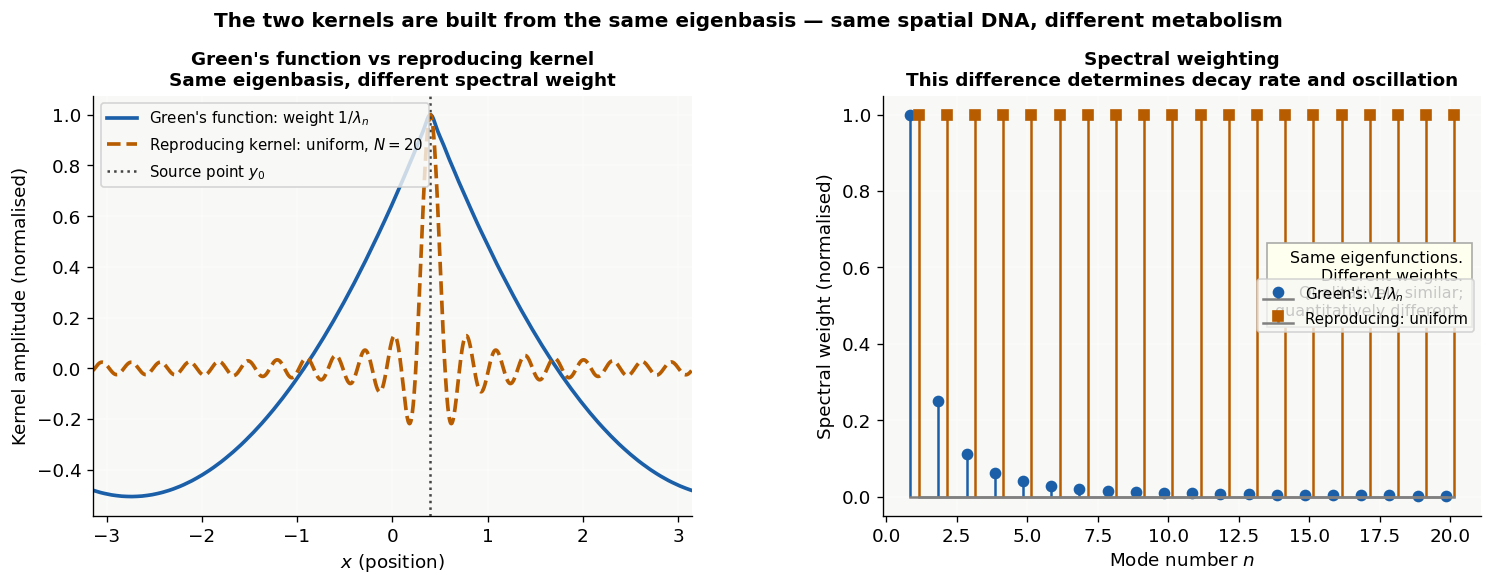

In [5]:
# --- Green's function vs reproducing kernel: spectral comparison ---
# 1D periodic domain: eigenfunctions e^{inx}, eigenvalues n^2
# Show how spectral weighting shapes the spatial response

x_arr = np.linspace(-np.pi, np.pi, 2000)
y0_val = 0.4  # source point (in radians)
N_cutoff = 20

# Green's function: sum_n phi_n(x) phi_n(y0)^* / lambda_n  (skip n=0)
G_kernel = np.zeros(len(x_arr))
for n in range(1, N_cutoff*3):  # use many more modes for convergence
    w = 1.0 / n**2  # 1/lambda weighting
    G_kernel += (np.cos(n*(x_arr - y0_val)) * w)
G_kernel /= np.pi  # normalise

# Reproducing kernel: sum_{|m|<=N} phi_m(x) phi_m(y0)^*  (uniform weighting)
K_kernel = np.zeros(len(x_arr))
for m in range(-N_cutoff, N_cutoff+1):
    K_kernel += np.cos(m*(x_arr - y0_val))
K_kernel /= (2*np.pi)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.subplots_adjust(top=0.84, bottom=0.14, left=0.08, right=0.97, wspace=0.32)

# Left: the two kernels at the same source point
axes[0].plot(x_arr, G_kernel/np.max(np.abs(G_kernel)),
             '#1a5fa8', linewidth=2.2, label=r"Green's function: weight $1/\lambda_n$")
axes[0].plot(x_arr, K_kernel/np.max(np.abs(K_kernel)),
             '#b85c00', linewidth=2.2, linestyle='--',
             label=f'Reproducing kernel: uniform, $N={N_cutoff}$')
axes[0].axvline(y0_val, color='#444', linewidth=1.5, linestyle=':', label='Source point $y_0$')
axes[0].set_xlabel('$x$ (position)', fontsize=11)
axes[0].set_ylabel('Kernel amplitude (normalised)', fontsize=11)
axes[0].set_title("Green's function vs reproducing kernel\nSame eigenbasis, different spectral weight",
                  fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9, loc='upper left')
axes[0].grid(True, alpha=0.4)
axes[0].set_xlim(-np.pi, np.pi)

# Right: spectral weights as function of mode number
n_modes = np.arange(1, N_cutoff+1)
w_green = 1.0/n_modes**2
w_repro = np.ones(N_cutoff)/N_cutoff  # flat up to N

ax2 = axes[1]
ax2.stem(n_modes - 0.15, w_green/w_green[0], linefmt='#1a5fa8', markerfmt='o',
         basefmt='grey', label=r"Green's: $1/\lambda_n$")
ax2.stem(n_modes + 0.15, w_repro/w_repro[0], linefmt='#b85c00', markerfmt='s',
         basefmt='grey', label='Reproducing: uniform')
ax2.set_xlabel('Mode number $n$', fontsize=11)
ax2.set_ylabel('Spectral weight (normalised)', fontsize=11)
ax2.set_title("Spectral weighting\nThis difference determines decay rate and oscillation",
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.4)
ax2.text(0.97, 0.55,
    "Same eigenfunctions.\nDifferent weights.\nQualitatively similar;\nquantitatively different.",
    transform=ax2.transAxes, ha='right', va='center', fontsize=9.5,
    bbox=dict(fc='#fffff0', ec='#aaa', pad=5))

fig.suptitle('The two kernels are built from the same eigenbasis — same spatial DNA, different metabolism',
             fontsize=12, fontweight='bold')
plt.show()


---
## 4. Why the Instinct Is Correct

Despite the breaks in the analogy, the physical instinct — that a hole acts like an obstacle and creates distance-dependent features — is correct. The reason is deeper than any specific kernel: it follows from the shared eigenbasis.

Both the Green's function and the reproducing kernel are built from the same set of eigenfunctions $\{\varphi_n\}$ of the same operator $L$ on the same domain $\Omega$. They are both of the form:

$$K(x,y) = \sum_n w_n\,\varphi_n(x)\,\bar{\varphi}_n(y) \tag{8}$$

with different weight sequences $\{w_n\}$. The weight sequence controls the quantitative details — how fast the kernel decays, how oscillatory it is, how smooth. But the spatial structure — where the kernel peaks, where it has zeros, how it interacts with the domain geometry — is set by the eigenfunctions, which are the same in both cases.

This is why the instinct works. When you look at a physical wave field and see scattering from an obstacle, the spatial pattern you recognize — enhanced amplitude near the obstacle, decay away from it, interference fringes at the eigenfunction wavelengths — is carried by the eigenfunctions. When you look at gapped spectral data and see phantom features near the gap, the spatial pattern is carried by the same eigenfunctions, evaluated at the same points, summed with different weights. The patterns are recognizably similar because they are built from the same spatial building blocks.

The eigenfunctions of $L$ encode the **spatial DNA** of the domain. Both the Green's function and the reproducing kernel are expressions of that DNA. A perturbation localized at $x_G$ — whether it is a physical obstacle or a measurement gap — produces a response at $x$ that is a sum of eigenfunctions evaluated at both $x_G$ and $x$. The response is strong when $x$ is close to $x_G$ (constructive interference among the eigenfunctions) and weak when $x$ is far (destructive interference). This behavior is a property of the eigenbasis geometry, not the specific kernel, which is why it survives the change from physical scattering to analysis-domain scattering.

The instinct that a hole creates distance-dependent features is therefore correct for a precise mathematical reason: the reproducing kernel and the Green's function are both localized around the source point, because both are finite sums (or convergent infinite sums) of eigenfunctions evaluated at the source, and eigenfunctions of local differential operators on bounded domains cannot constructively interfere at points far from the source without including arbitrarily high frequencies. **Finite bandwidth concentrates the kernel's main lobe, but does not eliminate sidelobes.** *(Audit fix: "finite spatial range" is false — the reproducing kernel K_N has global sidelobes at every point, decaying as ~1/|x−y| with N-dependent oscillation. The correct statement is that the main-lobe width scales as 1/√λ_N, while sidelobes persist globally. This is a consequence of the Dirichlet/Fejér kernel structure, not a contradiction of the uncertainty principle — both the Green's function and the reproducing kernel are localized in their main lobe without having compact support.)*


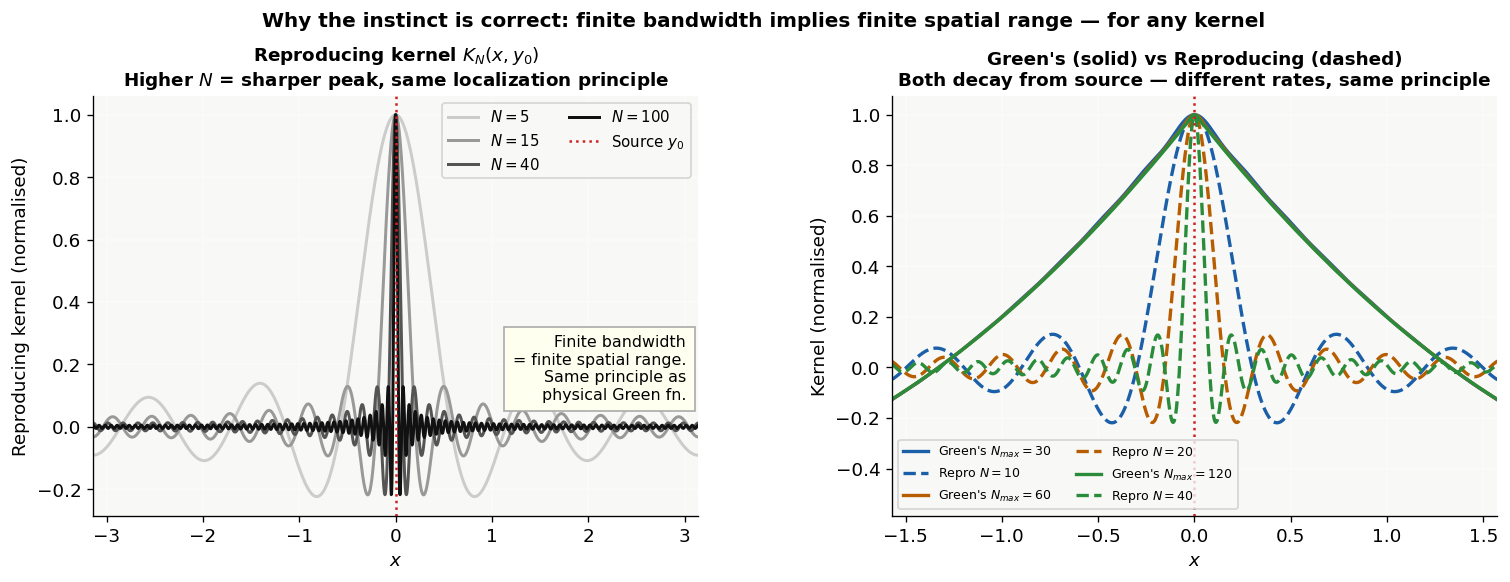

In [6]:
# --- Demonstrate finite-bandwidth localization: main-lobe sharpening (Green's fn: power-law decay; K_N: concentrated main lobe + global sidelobes) ---
# Show that increasing N sharpens the reproducing kernel peak (localization)
# and that the Green's function with more modes gives smoother but also localized response\n
x_arr = np.linspace(-np.pi, np.pi, 2000)
y_src = 0.0  # source at 0

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.subplots_adjust(top=0.84, bottom=0.14, left=0.07, right=0.97, wspace=0.32)

# Left: reproducing kernel for different N
N_list = [5, 15, 40, 100]
colors_N = ['#cccccc', '#999999', '#555555', '#111111']
for N_val, col in zip(N_list, colors_N):
    K = sum(np.cos(m*(x_arr - y_src)) for m in range(-N_val, N_val+1)) / (2*np.pi)
    K_norm = K / K.max()
    axes[0].plot(x_arr, K_norm, color=col, linewidth=1.8, label=f'$N={N_val}$')
axes[0].axvline(y_src, color='#cc2222', linewidth=1.5, linestyle=':', label='Source $y_0$')
axes[0].set_xlabel('$x$', fontsize=11)
axes[0].set_ylabel('Reproducing kernel (normalised)', fontsize=11)
axes[0].set_title('Reproducing kernel $K_N(x,y_0)$\nHigher $N$ = sharper peak, same localization principle',
                  fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9, ncol=2)
axes[0].grid(True, alpha=0.4)
axes[0].set_xlim(-np.pi, np.pi)
axes[0].text(0.98, 0.35,
    'Finite bandwidth\n= concentrated main lobe\n(sidelobes persist).\nSame principle as\nphysical Green fn.',
    transform=axes[0].transAxes, ha='right', va='center', fontsize=9.5,
    bbox=dict(fc='#fffff0', ec='#aaa', pad=5))

# Right: compare peak widths — both kernels peak at source
N_compare = [10, 20, 40]
cols = ['#1a5fa8', '#b85c00', '#2a8c3a']
for N_val, col in zip(N_compare, cols):
    K_rep = sum(np.cos(m*(x_arr-y_src)) for m in range(-N_val, N_val+1))/(2*np.pi)
    G_fn = sum(np.cos(n*(x_arr-y_src))/n**2 for n in range(1, N_val*3))/ np.pi
    K_rep_n = K_rep/K_rep.max()
    G_fn_n = G_fn/G_fn.max()
    axes[1].plot(x_arr, G_fn_n, color=col, linewidth=2,
                 label=fr"Green's $N_{{max}}={N_val*3}$")
    axes[1].plot(x_arr, K_rep_n, color=col, linewidth=2, linestyle='--',
                 label=fr'Repro $N={N_val}$')
axes[1].axvline(y_src, color='#cc2222', linewidth=1.5, linestyle=':')
axes[1].set_xlabel('$x$', fontsize=11)
axes[1].set_ylabel('Kernel (normalised)', fontsize=11)
axes[1].set_title("Green's (solid) vs Reproducing (dashed)\nBoth decay from source — different rates, same principle",
                  fontsize=11, fontweight='bold')
axes[1].legend(fontsize=7.5, ncol=2)
axes[1].grid(True, alpha=0.4)
axes[1].set_xlim(-np.pi/2, np.pi/2)  # zoom in

fig.suptitle(
    "Why the instinct is correct: finite bandwidth concentrates the kernel's main lobe"
    " — sidelobes persist globally",
    fontsize=12, fontweight='bold')
plt.show()


---
## 5. The Three Kernels: A Unified View

The phantom eigenmode paper (v8) and this companion document together identify three kernel objects that control three aspects of the problem. All three are built from the same eigenbasis; they differ only in what they measure.

| Kernel | Formula | Role | Physical analogy |
|--------|---------|------|-----------------|
| **Coupling kernel** | $K_{mn} = \int_G \varphi_n\bar{\varphi}_m$ | Gap fingerprint in coefficient space | T-matrix |
| **Reproducing kernel** | $K_N(x,y) = \sum_{m\leq N}\varphi_m(x)\bar{\varphi}_m(y)$ | Spatial pattern of phantom field | Green's function |
| **Concentration operator** | $C_N = P_N\chi_G P_N$ | Stability and conditioning of recovery | Total cross-section |

**The coupling kernel $K_{mn}$** determines which mode indices receive phantom energy and how much. It is a property of the hole geometry — different signals through the same hole get the same matrix $K$ applied, just with different input vectors $c$. Analogous to the T-matrix of a physical scatterer.

**The reproducing kernel $K_N(x,y)$** determines the spatial pattern of the phantom field for finite bandwidth. It has a main lobe of width $\sim 1/\sqrt{\lambda_N}$ concentrated near $y$, with persistent global oscillatory sidelobes — there is no monotone decay in $|x-y|$. It is analogous to the Green's function of the wave operator, but with flat spectral weighting (uniform across modes $m \leq N$) instead of $1/\lambda_n$ weighting. This is the kernel that explains the main-lobe spatial structure of phantom features.

**The concentration operator $C_N$** has eigenvalues $\mu_j$ measuring how much a bandlimited combination can concentrate inside the gap. It determines whether phantom suppression is feasible and how ill-conditioned the recovery problem is. Analogous to the scattering cross-section, but the analogy is directional: $\mu_{\max}(C_N)$ — the largest eigenvalue — measures the maximum fraction of bandlimited energy the gap can capture in a single direction, corresponding to the peak scattering cross-section. The full spectrum $\{\mu_j\}$ corresponds to the angle-resolved cross-section. Large $\mu_{\max}$ means the gap is a strong "scatterer" in its worst direction and inversion is ill-conditioned. The analogy is suggestive but not literal: $\mu_{\max}$ is a dimensionless energy fraction, while a physical cross-section has units of area.

The correspondence is:

$$\text{T-matrix} \leftrightarrow K_{mn} \quad\text{(coupling structure)}$$
$$\text{Green's function} \leftrightarrow K_N(x,y) \quad\text{(spatial response)}$$
$$\text{Cross-section} \leftrightarrow \mu_{\max}(C_N) \quad\text{(largest concentration eigenvalue — effective scattering strength; the full spectrum $\{\mu_j\}$ is the more complete analog)}$$

All six objects are built from the same eigenfunctions. The physical scattering versions use the Green's function weighting ($1/\lambda_n$); the analysis versions use the reproducing kernel weighting (uniform with cutoff). The qualitative behavior — localized source, main-lobe-concentrated response with oscillatory sidelobes, geometry-dependent structure, exact energy budget — is shared because it comes from the eigenbasis, not the weighting.


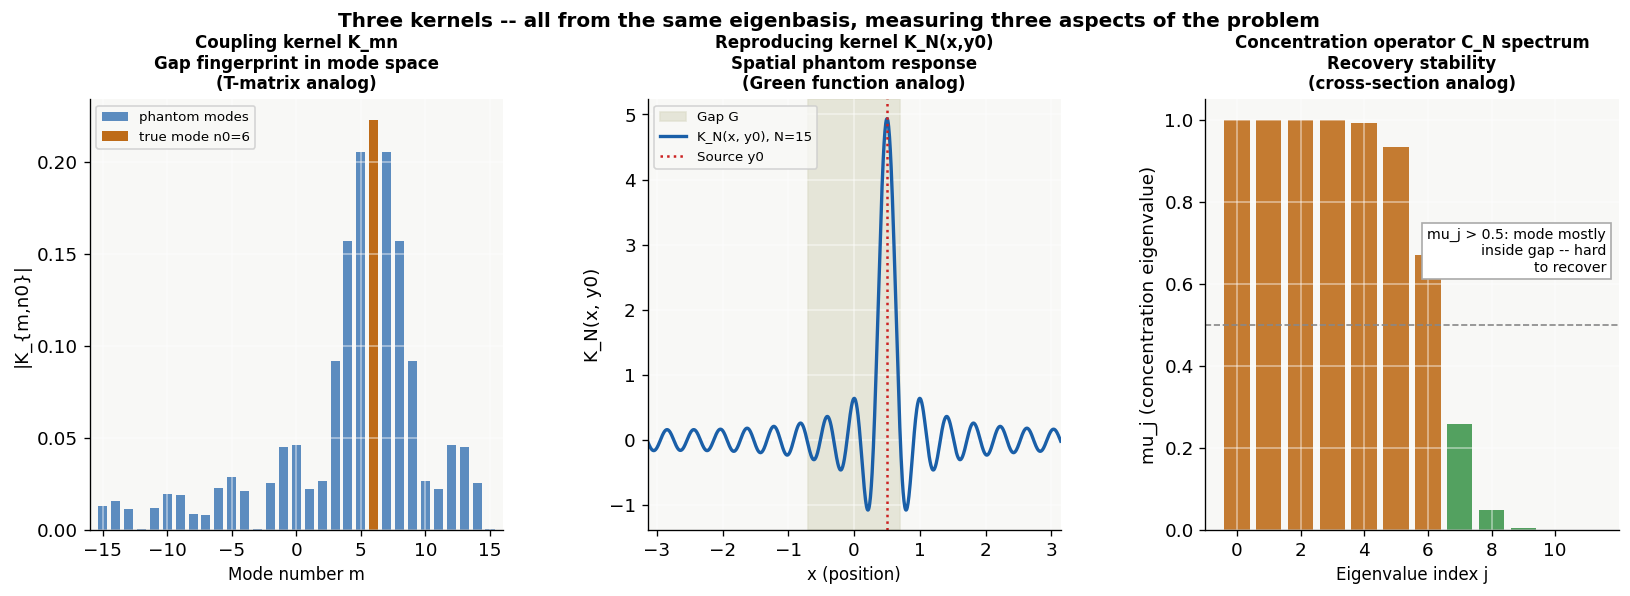

In [7]:
# Three kernels side by side
x_arr = np.linspace(-np.pi, np.pi, 1000)
a_gap = 0.7; N_cut = 15
n0 = 6
K_mn = np.array([np.sin((n0-m)*a_gap)/(np.pi*(n0-m)) if m != n0 else a_gap/np.pi
                 for m in range(-N_cut, N_cut+1)])
m_arr = np.arange(-N_cut, N_cut+1)
y0_src = 0.5
K_N = np.array([sum(np.cos(m*(xv-y0_src)) for m in range(-N_cut, N_cut+1))/(2*np.pi)
                for xv in x_arr])
idx = np.arange(-N_cut, N_cut+1)
M1, M2 = np.meshgrid(idx, idx)
diff = M1 - M2
safe_diff = np.where(diff==0, 1, diff)
C_mat = np.where(diff==0, a_gap/np.pi, np.sin(diff*a_gap)/(np.pi*safe_diff))
mu_vals = np.linalg.eigvalsh(C_mat)[::-1]

fig = plt.figure(figsize=(14, 5.2))
fig.subplots_adjust(left=0.06, right=0.97, top=0.84, bottom=0.15, wspace=0.35)
ax1 = fig.add_subplot(131); ax2 = fig.add_subplot(132); ax3 = fig.add_subplot(133)

# Coupling kernel
ax1.bar(m_arr[m_arr != n0], np.abs(K_mn[m_arr != n0]),
        color='#1a5fa8', alpha=0.7, width=0.7, label='phantom modes')
ax1.bar([n0], [K_mn[list(m_arr).index(n0)]],
        color='#b85c00', alpha=0.9, width=0.7, label=f'true mode n0={n0}')
ax1.set_xlabel('Mode number m', fontsize=10)
ax1.set_ylabel('|K_{m,n0}|', fontsize=11)
ax1.set_title('Coupling kernel K_mn\n'
              'Gap fingerprint in mode space\n'
              '(T-matrix analog)', fontsize=10, fontweight='bold')
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.4)
ax1.set_xlim(-N_cut-1, N_cut+1)

# Reproducing kernel
ax2.axvspan(-a_gap, a_gap, color='#ddddcc', alpha=0.7, label='Gap G')
ax2.plot(x_arr, K_N, '#1a5fa8', linewidth=2, label=f'K_N(x, y0), N={N_cut}')
ax2.axvline(y0_src, color='#cc2222', linewidth=1.5, linestyle=':', label='Source y0')
ax2.set_xlabel('x (position)', fontsize=10)
ax2.set_ylabel('K_N(x, y0)', fontsize=11)
ax2.set_title('Reproducing kernel K_N(x,y0)\n'
              'Spatial phantom response\n'
              '(Green function analog)', fontsize=10, fontweight='bold')
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.4)
ax2.set_xlim(-np.pi, np.pi)

# Concentration spectrum
n_shown = 12
ax3.bar(range(n_shown), mu_vals[:n_shown],
        color=['#b85c00' if m > 0.5 else '#2a8c3a' for m in mu_vals[:n_shown]], alpha=0.8)
ax3.axhline(0.5, color='#888', linewidth=1, linestyle='--')
ax3.set_xlabel('Eigenvalue index j', fontsize=10)
ax3.set_ylabel('mu_j (concentration eigenvalue)', fontsize=11)
ax3.set_title('Concentration operator C_N spectrum\n'
              'Recovery stability\n'
              '(cross-section analog)', fontsize=10, fontweight='bold')
ax3.text(0.97, 0.6, 'mu_j > 0.5: mode mostly\ninside gap -- hard\nto recover',
         transform=ax3.transAxes, ha='right', fontsize=8.5,
         bbox=dict(fc='white', ec='#aaa', pad=3))
ax3.grid(True, alpha=0.4)

fig.suptitle('Three kernels -- all from the same eigenbasis, measuring three aspects of the problem',
             fontsize=12, fontweight='bold')
plt.show()


---
## 6. What Is Real and What Is Phantom

The scattering analogy, taken carelessly, can produce a false conclusion: that the visible features outside the gap are themselves phantom — that the three lobes of a cloverleaf, seen in measured data with a gap over the fourth, are artifacts created by the hole. **This is wrong as a spatial claim and must be stated precisely.**

### 6.1 The Energy Budget

For a single normalized true mode $f = c\varphi_n$ with missing $L^2$-mass fraction $a = \int_G|\varphi_n|^2$, three energies matter:

$$|f|^2 = |c|^2 \quad\text{(true signal energy)} \tag{9}$$
$$|Mf|^2 = |c|^2(1-a) \quad\text{(energy surviving after masking)} \tag{10}$$
$$\sum_{m\neq n}|\hat{c}_m|^2 = |c|^2 a(1-a) \quad\text{(phantom modal energy)} \tag{11}$$

The gap does not add physical energy. It removes $a|c|^2$. The surviving measured energy $|c|^2(1-a)$ is then redistributed across the wrong modal coordinates when $Mf$ is expanded in the original eigenbasis. That redistribution is exact, and in the paper it is the precise meaning of "phantom energy." No energy is created; real energy is misattributed.

### 6.2 Three Levels of Real vs. Phantom

The distinction between real and phantom operates at three levels, and conflating them produces errors:

**Level 1: Raw spatial data outside $G$.** Outside the gap, the measured field equals the true field pointwise: $Mf(x) = f(x)$ for $x \notin G$. The three visible lobes of a cloverleaf are real spatial measurements of a real physical field. You can place a sensor at any of those positions and measure the correct amplitude. Nothing about the spatial data outside $G$ is phantom. It is the true field, unmodified.

**Level 2: Modal coefficients at $m \neq n_0$.** The coefficients $\hat{c}_m = \langle Mf, \varphi_m\rangle$ for $m \neq n_0$ are 100% artifact. The true field has zero energy at those eigenvalues. The modal decomposition says "this field contains energy at eigenvalue $\lambda_m$." That statement is false. The mask created a false spectral narrative. Remove the gap, and every off-diagonal coefficient vanishes. The extra modes are completely and entirely artefactual.

**Level 3: Finite-bandwidth spatial reconstruction.** When the observer takes the corrupted coefficients $\{\hat{c}_m\}$ for $m \leq N$ and plots $\sum_{m\leq N}\hat{c}_m\varphi_m(x)$, the result does not equal $f(x)$ outside $G$. The finite sum has Gibbs-like artifacts, and the phantom coefficient contributions concentrate near the gap via the reproducing kernel. In this reconstructed picture, the near-gap features really are "mostly phantom" in the sense that the reconstruction error is dominated by phantom coefficient contributions, and the spatial pattern of that error is localized near the gap. This is the level at which the original observation operates.

### 6.3 The Decomposition Inside the Measured Region

The split $Mf = (1-a)c\varphi_{n_0} + f_{\text{phantom}}$ is the key. Outside $G$, both terms are proportional to $\varphi_{n_0}$:

$$(1-a)c\varphi_{n_0}(x) + a\cdot c\varphi_{n_0}(x) = c\varphi_{n_0}(x) = f(x) \quad\text{for } x\notin G$$

The observer sees $f(x)$ — the true field — at every measured point. But the modal decomposition attributes $(1-a)$ of the energy to "the real mode $n_0$" and distributes $a$ of the energy across "other modes that are also excited." That attribution is entirely false. The "other modes" are phantom. The spatial data is real. The explanation is fake.

The eye is seeing real data. The spectral decomposition is telling a false multi-mode story about that data. The distinction matters: **phantom modes are completely artefactual; outside-gap field values are not artefactual at all; the artefact is the modal explanation, not the measurement.**

### 6.4 Why This Matters for the Scattering Analogy

In physical scattering, the scattered field is a real, measurable wavefield. The scatterer conserves total energy globally and redistributes it directionally: constructive interference increases amplitude at some exterior points, destructive interference reduces it at others. The scatterer does not create energy — it redirects it.

In analysis-domain "scattering," the phantom field does not carry physical energy. No energy is created. Outside the gap, the phantom field and the "true mode" piece sum to the true field — so the phantom is not an addition; it is a reattribution. The scattering analogy describes the mechanism (source on $\partial G$, kernel-mediated response, main-lobe-concentrated spatial structure) but not the energetics. Physical scattering **redistributes** energy — real, measurable amplitude changes at exterior points, with global energy conserved; analysis scattering **renames** existing energy without changing any measured amplitude.

This is the precise sense in which the gap acts like an obstacle: it creates the same spatial coupling structure and the same distance-dependent response pattern, but as a measurement phenomenon, not as physical energy creation. The source is real (the commutator on $\partial G$). The coupling is real (the matrix $K$). The spatial pattern is real (the reproducing kernel). The energy is not new — it is old energy wearing false labels.

### 6.5 The Original Observation, Precisely Stated

The original observation was: "I see three features near a hole, and my instinct says the hole caused them." The precise version, accounting for the three levels above, is:

The three features are **real spatial measurements of a real field** (Level 1). But the spectral interpretation that would be placed on them — "these are manifestations of modes at eigenvalues $\lambda_m$ for $m\neq n_0$" — is **entirely manufactured by the hole** (Level 2). And in a finite-bandwidth spectral reconstruction, the visible pattern near the gap is dominated by the phantom coefficient contributions, producing features whose spatial structure is shaped by the reproducing kernel centered at the gap — so the reconstruction itself shows distance-dependent artifacts even though the raw data does not (Level 3).

The instinct was correct at Level 2 (the modal story is fake) and at Level 3 (the reconstruction shows gap-localized artifacts). It was imprecise at Level 1 (the raw spatial data is real). The physically operative regime — the one in which practitioners actually work — is Level 3, because nobody examines raw spatial data; they examine spectrally processed data. In that regime, the scattering analogy holds: the hole creates features near the gap, the features are concentrated in the main lobe (with global sidelobes), and the pattern is determined by the gap geometry.


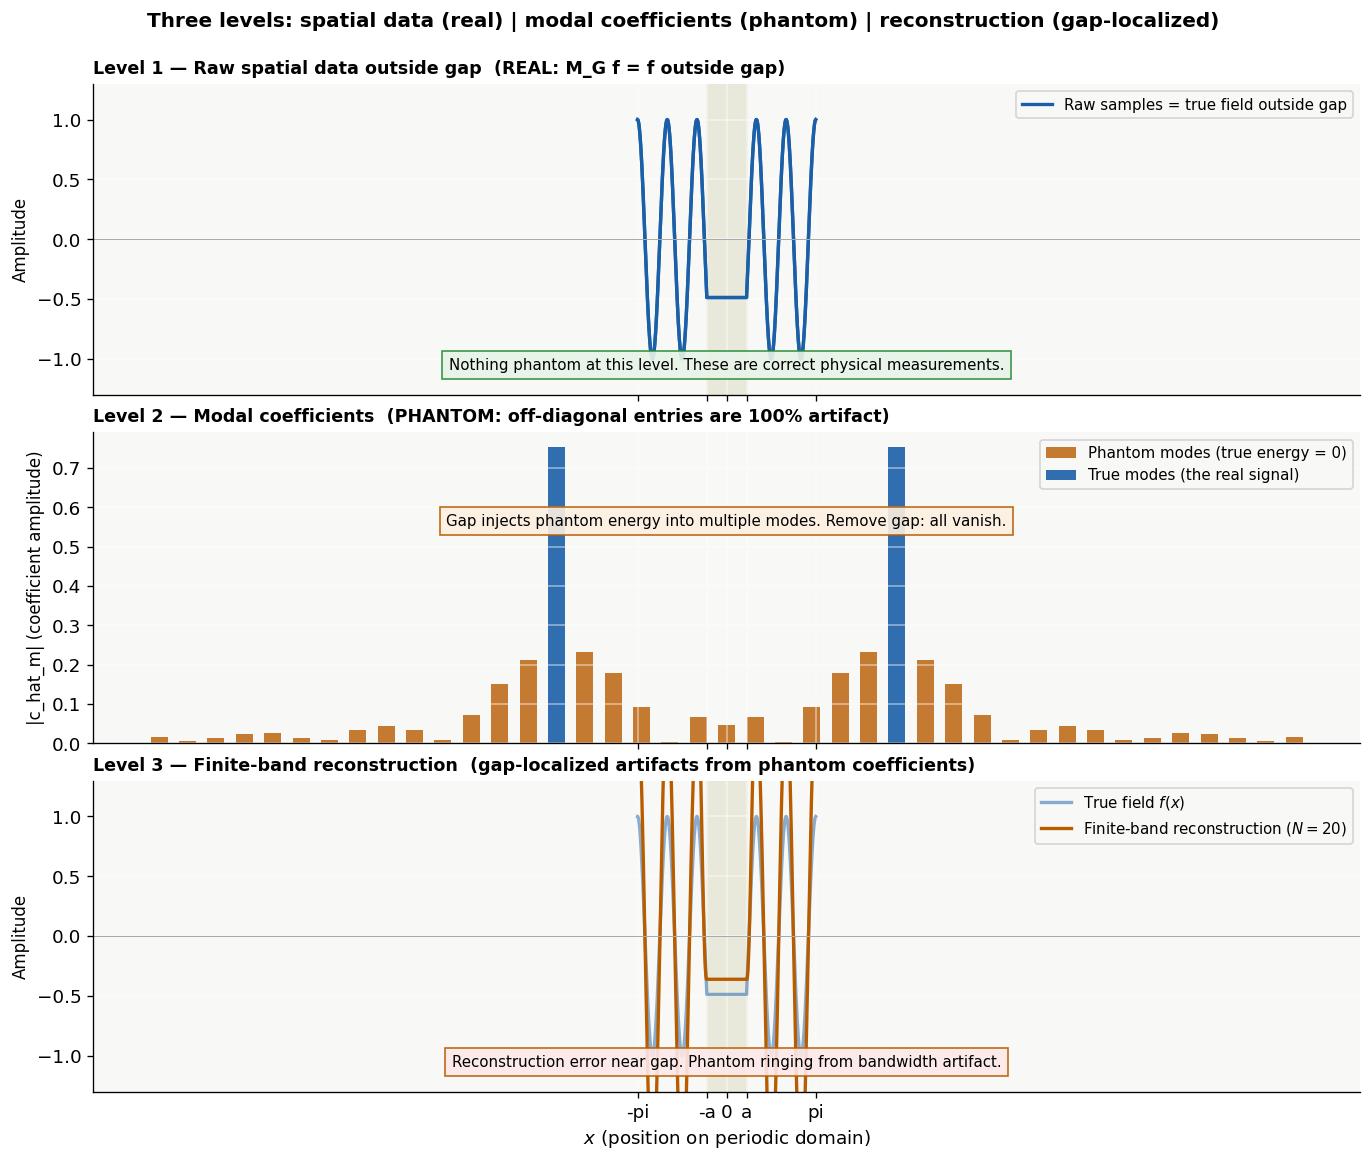

Missing mass a_n = 0.223, phantom energy = 0.1732


In [8]:
# --- Three levels: spatial data, modal coefficients, reconstruction ---
# 1D toy: true field = cos(6x), gap G = [-0.7, 0.7]

k0, a_gap_v, N_bw = 6, 0.7, 20
Nx = 2000
x_v = np.linspace(-np.pi, np.pi, Nx, endpoint=False)
gap_v = np.abs(x_v) <= a_gap_v
out_v = ~gap_v
f_true = np.cos(k0*x_v)
a_n_v = a_gap_v/np.pi  # missing mass

# Modal coefficients in complex-exponential basis {e^{imx}}_{m in Z}:
# c_hat_m = <M f, phi_m> = (1/(2 pi)) int_{-pi}^{pi} f_masked(x) e^{-imx} dx
# For f = cos(k0 x) = (1/2)(e^{ik0 x} + e^{-ik0 x}), the true coefficients are 1/2 at m=+-k0.
def Kmk(m, k0, a): return np.sin((k0-m)*a)/(np.pi*(k0-m)) if m != k0 else a/np.pi

# Finite-band reconstruction using complex-exp projection
f_masked = f_true.copy(); f_masked[gap_v] = 0
c_hat = {}
f_recon_c = np.zeros(Nx, dtype=complex)
for m in range(-N_bw, N_bw+1):
    c_m = np.trapezoid(f_masked * np.exp(-1j * m * x_v), x_v) / (2*np.pi)
    c_hat[m] = c_m
    f_recon_c += c_m * np.exp(1j * m * x_v)
f_recon = f_recon_c.real

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.subplots_adjust(top=0.92, bottom=0.08, left=0.09, right=0.97, hspace=0.12)

# Panel 1: Level 1 — raw spatial data
ax = axes[0]
ax.axvspan(-a_gap_v, a_gap_v, color='#e8e8d8', alpha=0.9)
ax.plot(x_v[out_v], f_true[out_v], '#1a5fa8', linewidth=2,
        label='Raw samples = true field outside gap')
ax.plot(x_v[out_v], f_true[out_v], '#1a5fa8', linewidth=2)
ax.axhline(0, color='#aaa', linewidth=0.6)
ax.set_ylabel('Amplitude', fontsize=10)
ax.set_title('Level 1 — Raw spatial data outside gap  (REAL: M_G f = f outside gap)',
             fontsize=10.5, fontweight='bold', loc='left')
ax.legend(fontsize=9, loc='upper right')
ax.set_ylim(-1.3, 1.3); ax.grid(True, alpha=0.4)
ax.text(0.5, 0.08, 'Nothing phantom at this level. These are correct physical measurements.',
        transform=ax.transAxes, ha='center', fontsize=9,
        bbox=dict(fc='#e8f4e8', ec='#2a8c3a', alpha=0.9, pad=4))

# Panel 2: Level 2 — modal coefficients
ax2 = axes[1]
m_arr_v = np.arange(-N_bw, N_bw+1)
c_vals = np.array([c_hat[m] for m in m_arr_v])
phantom_mask = (m_arr_v != k0) & (m_arr_v != -k0)
ax2.bar(m_arr_v[phantom_mask], np.abs(c_vals[phantom_mask]),
        color='#b85c00', alpha=0.8, width=0.6, label='Phantom modes (true energy = 0)')
ax2.bar([k0, -k0],
        [abs(c_hat[k0]), abs(c_hat[-k0])],
        color='#1a5fa8', alpha=0.9, width=0.6, label='True modes (the real signal)')
ax2.set_ylabel('|c_hat_m| (coefficient amplitude)', fontsize=10)
ax2.set_title('Level 2 — Modal coefficients  (PHANTOM: off-diagonal entries are 100% artifact)',
              fontsize=10.5, fontweight='bold', loc='left')
ax2.legend(fontsize=9, loc='upper right')
ax2.grid(True, alpha=0.4)
ax2.text(0.5, 0.70, 'Gap injects phantom energy into multiple modes. Remove gap: all vanish.',
        transform=ax2.transAxes, ha='center', fontsize=9,
        bbox=dict(fc='#fdf0e0', ec='#b85c00', alpha=0.9, pad=4))

# Panel 3: Level 3 — reconstruction
ax3 = axes[2]
ax3.axvspan(-a_gap_v, a_gap_v, color='#e8e8d8', alpha=0.9)
ax3.plot(x_v[out_v], f_true[out_v], '#1a5fa8', linewidth=2, label='True field $f(x)$', alpha=0.5)
ax3.plot(x_v[out_v], f_recon[out_v], '#b85c00', linewidth=2,
         label=f'Finite-band reconstruction ($N={N_bw}$)')
ax3.axhline(0, color='#aaa', linewidth=0.6)
ax3.set_xlabel('$x$ (position on periodic domain)', fontsize=11)
ax3.set_ylabel('Amplitude', fontsize=10)
ax3.set_title('Level 3 — Finite-band reconstruction  (gap-localized artifacts from phantom coefficients)',
              fontsize=10.5, fontweight='bold', loc='left')
ax3.legend(fontsize=9, loc='upper right')
ax3.set_ylim(-1.3, 1.3); ax3.grid(True, alpha=0.4)
ax3.set_xticks([-np.pi, -a_gap_v, 0, a_gap_v, np.pi])
ax3.set_xticklabels(['-pi', '-a', '0', 'a', 'pi'])
ax3.text(0.5, 0.08, 'Reconstruction error near gap. Phantom ringing from bandwidth artifact.',
        transform=ax3.transAxes, ha='center', fontsize=9,
        bbox=dict(fc='#fde8e8', ec='#b85c00', alpha=0.9, pad=4))

fig.suptitle('Three levels: spatial data (real) | modal coefficients (phantom) | reconstruction (gap-localized)',
             fontsize=12, fontweight='bold')
plt.show()
print(f"Missing mass a_n = {a_n_v:.3f}, phantom energy = {a_n_v*(1-a_n_v):.4f}")


---
## 7. The Gap as Instrument

The scattering analogy captures the mechanism of phantom fabrication. But there is a more practical framing that may better serve the paper's applied audience: **the gap is not mainly a missing-data problem. It is a measurement-operator mismatch problem.**

### 7.1 The Transfer Function You Didn't Model

Reality gives you a field $f$. The instrument gives you $y = Mf$, where $M = I - \chi_G$. The analyst then projects $y$ onto the original modal basis and gets $\hat{c} = Ac$. The hole is acting as a hidden, geometry-dependent transfer function in modal space. It does not create new physics. It corrupts the coordinates in which the physics is being inferred.

This is the language of instrument modeling. Every measurement system has a transfer function — a linear operator transforming the true signal into the observed signal. For a well-characterized instrument, the analyst models the transfer function and deconvolves. The problem with a measurement gap is not that $M$ is complicated — it is trivially simple, a binary mask — but that the analyst typically **does not model it at all**. The modal projection $\hat{c}_m = \langle y, \varphi_m\rangle$ is performed as if the instrument were the identity. The gap is an unmodeled instrument response.

The three-level picture of §6 translates directly:
- *Sample level:* the instrument output $y = Mf$ is correct at every sampled point. The instrument is not lying about what it measures; it is simply not measuring everywhere.
- *Coefficient level:* projecting the instrument output onto the modal basis without modeling the instrument produces corrupted coefficients. The off-diagonal entries of $A$ are the instrument's modal cross-talk — deterministic, geometry-dependent, fully predictable from the mask.
- *Interpretation level:* the corrupted coefficients are coherent and valid-looking. Downstream methods treat them as genuine physical content. The false coefficients pass every sanity check that does not explicitly test for mask-induced coupling.

### 7.2 Missingness vs. False Attribution

Ordinary missing data produces **uncertainty**. You know less. The gap is a hole in your knowledge, and any inference about the gap interior carries explicit uncertainty.

Phantom fabrication is worse than uncertainty. It produces **structured false attribution**. The system does not say "I don't know." It says "here are the modes that are excited" — and the answer is wrong. The false content is deterministic (not random), coherent (spatially structured as valid eigenfunctions), and consistent with the measured data (because outside $G$ the phantom plus the attenuated true mode sums to $f$). There is no internal inconsistency to flag the error unless the analyst explicitly checks the data against the modal reconstruction.

The gap does not just make you know less. It can make you believe the wrong thing. It takes real measurements — correct at every sampled point — and assigns them to false modal causes. The spectral narrative becomes a believable lie about which modes, sources, or mechanisms generated the data.

### 7.3 The Practical Consequence

The shortest version of the paper's practical message:

> *A measurement gap leaves the observed samples outside the hole real, but it can systematically assign those real samples to false modal causes.*

Or more bluntly:

> *The hole does not just hide truth; it can manufacture a believable lie about what caused the truth you still see.*

The scatterer analogy explains the mechanism: source on $\partial G$, kernel-mediated coupling, distance-dependent spatial pattern. The instrument framing explains the remedy: the gap is part of the instrument. If you do not model that instrument response, downstream interpretation confuses hole-induced structure with signal-induced structure. Modeling the mask is not optional post-processing; it is calibration. The coupling matrix $K$ is the instrument's modal point-spread function, and ignoring it is equivalent to ignoring any other unmodeled instrument response.

Every spectral estimation pipeline operating on gapped data should either explicitly invert $A$ (deconvolution), constrain the solution to be sparse (compressed sensing), or at minimum flag the mode indices predicted by $K$ as candidate phantoms. The selection rules, energy identities, and concentration-operator bounds in the companion paper provide the quantitative tools for each strategy.

---
## 8. From Phantom Modes to Phantom Observables

"Misinterpretation" is too weak a word if the contaminated coefficients get fed into later computations. The issue is not just that a human tells the wrong story. The issue is that the pipeline can output quantities that are themselves false.

### 8.1 The Downstream Propagation

The true modal state is $c$. The mask produces $\hat{c} = Ac$. A downstream algorithm computes $Q(\hat{c})$. If the intended quantity was $Q(c)$, then the pipeline evaluates $Q(Ac)$. Unless $Q$ is specially invariant to the mask operator — unless $Q(Ac) = Q(c)$ for all $c$, a condition most diagnostics do not satisfy — the output is not "the right quantity with the wrong interpretation." It is a different quantity. **A numerically false derived observable.**

The three-level picture sharpens:
- Level 1: Outside the gap, raw samples are real.
- Level 2: The extra modal coefficients are fake.
- Level 3: Quantities computed from fake coefficients can become genuinely false derived information. Not interpretive mistakes — false pipeline outputs.

### 8.2 Pairwise Interactions and Nonlinear Diagnostics

Suppose a downstream routine forms pairwise modal interactions:

$$I_{mn} = \hat{c}_m\bar{\hat{c}}_n = \sum_{k,l} A_{mk}\bar{A}_{nl}\,c_k\bar{c}_l \tag{12}$$

Even if the true field has no content at $m$ or $n$, the computed interaction $I_{mn}$ can be nonzero purely through the off-diagonal entries of $A$ coupling energy from the true modes into phantom indices. This is not a wrong reading of a real interaction. It is a false computed interaction.

The same logic applies to every nonlinear or quadratic diagnostic:

- **Coherence estimates** between modes $m$ and $n$ can show nonzero coherence when the true modes are uncoupled, because the gap creates correlated phantom contributions at both indices from the same true mode.
- **Bispectra** accumulate phantom×phantom and phantom×true cross-terms. A bispectral peak at $(k_1, k_2)$ can appear without any physical three-wave interaction, purely from quadratic mixing in $A$.
- **Modal transfer functions** estimated from corrupted coordinates inherit the gap's fingerprint. An estimated energy transfer rate between modes $m$ and $n$ includes a mask-operator contribution with no physical basis.
- **Damping estimates** are corrupted because phantom coefficients evolve at the true mode's temporal frequency, not the phantom mode's natural frequency. A damping estimate tracking $\hat{c}_m(t)$ measures the true mode's decay but reports it as mode $m$'s damping.

### 8.3 False Detections as the Terminal Consequence

The terminal consequence is **false detection** — a pipeline output that promotes a phantom into a decision:

**Radar:** a thresholding or classifier stage promotes a phantom peak into a false target. Unlike noise-induced false alarms (stochastic, CFAR-controlled), gap-induced false detections are coherent and repeatable — same bins every time, as predicted by $K$.

**Ocean-wave partitioning:** spectral clustering on contaminated 2D spectra creates an extra wave system — a swell component from a direction with no physical source. The partitioning algorithm assigns wave height, period, and direction to a peak that is entirely gap-induced.

**Modal analysis:** secondary estimates — damping ratios, coupling coefficients, mode participation factors, fatigue-relevant stress combinations — computed from corrupted coordinates are false derived quantities. A structural engineer using phantom-contaminated modal amplitudes to estimate fatigue loading computes forces the structure does not experience.

In each case the pipeline computed a false number and reported it as a physical measurement. The gap created a phantom observable that propagated through the analysis chain and became a decision-relevant output.

### 8.4 The Sharpened Summary

The gap does not just create phantom modes. It can create phantom observables. The complete chain:

$$\text{Real field } f \;\to\; \text{masked field } Mf \;\to\; \text{corrupted coefficients } \hat{c}=Ac \;\to\; \text{false derived quantity } Q(Ac)\neq Q(c)$$

The raw field outside the hole is real. The extra modal coefficients are fake. And the quantities computed from those fake coefficients can become genuinely false pieces of derived information — false targets, false wave systems, false coupling estimates, false damping values — that propagate through the pipeline and produce false decisions.

This is why modeling the mask is not optional. It is not a matter of interpretation. It is a matter of computational correctness. An unmodeled gap is an unmodeled instrument response, and the derived observables computed without modeling it are, in general, **systematically and deterministically wrong** in a direction predicted by $K$.


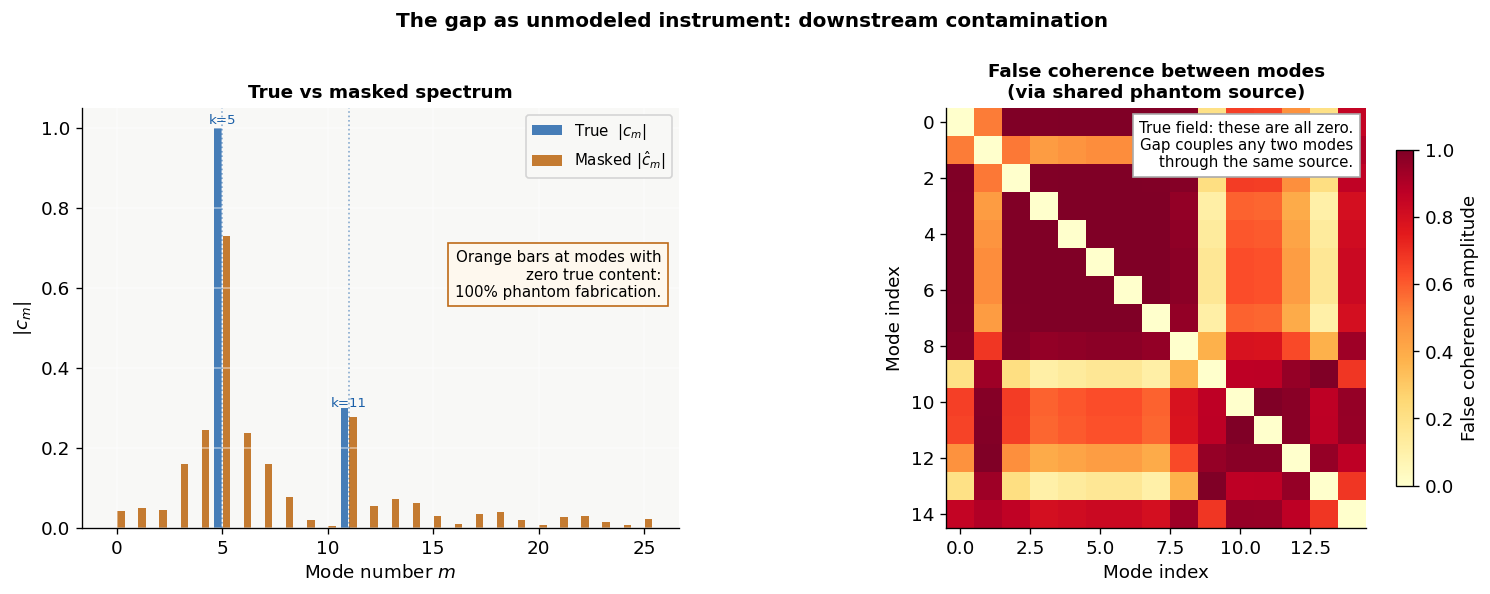

In [9]:
# Gap as unmodeled instrument: downstream contamination
a_gap_i = 0.8; N_modes_i = 25
x_i = np.linspace(-np.pi, np.pi, 3000, endpoint=False)
gap_i = np.abs(x_i) <= a_gap_i
k0_i, c0_i = 5, 1.0
k1_i, c1_i = 11, 0.3
f_i = c0_i*np.cos(k0_i*x_i) + c1_i*np.cos(k1_i*x_i)
f_masked_i = f_i.copy(); f_masked_i[gap_i] = 0

def get_coeffs(f, x, N):
    dx = x[1]-x[0]
    return {m: (np.sum(f)*dx/(2*np.pi) if m==0 else
               np.sum(f*np.cos(m*x))*dx/np.pi) for m in range(0,N+1)}

c_true   = get_coeffs(f_i,  x_i, N_modes_i)
c_masked = get_coeffs(f_masked_i, x_i, N_modes_i)
modes = np.arange(0, N_modes_i+1)
ct = np.array([abs(c_true.get(m,0))   for m in modes])
cm = np.array([abs(c_masked.get(m,0)) for m in modes])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.subplots_adjust(top=0.82, bottom=0.12, left=0.07, right=0.97, wspace=0.35)

# Left: true vs masked spectrum
ax = axes[0]
ax.bar(modes-0.2, ct,  0.35, color='#1a5fa8', alpha=0.8, label='True  $|c_m|$')
ax.bar(modes+0.2, cm,  0.35, color='#b85c00', alpha=0.8, label=r'Masked $|\hat{c}_m|$')
for ki, ci in [(k0_i,c0_i),(k1_i,c1_i)]:
    ax.axvline(ki, color='#1a5fa8', linewidth=1, linestyle=':', alpha=0.5)
    ax.annotate(f'k={ki}', xy=(ki, ci*1.01), fontsize=8,
                color='#1a5fa8', ha='center')
ax.set_xlabel('Mode number $m$', fontsize=11)
ax.set_ylabel('$|c_m|$', fontsize=11)
ax.set_title('True vs masked spectrum', fontsize=11, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.4)
ax.text(0.97, 0.55,
    'Orange bars at modes with\nzero true content:\n100% phantom fabrication.',
    transform=ax.transAxes, ha='right', fontsize=9,
    bbox=dict(fc='#fff8ee', ec='#b85c00', alpha=0.9, pad=4))

# Right: false coherence matrix
# False coherence between modes m1, m2 via source k0:
# |K_{m1,k0}| * |K_{m2,k0}| / sqrt(sum_m |K_{m,k0}|^2)^2
n_show = 15
def Kmk_1d(m, k, a): return a/np.pi if m==k else np.sin((k-m)*a)/(np.pi*(k-m))
# Coupling from source modes k0_i and k1_i
K0 = np.array([abs(Kmk_1d(m, k0_i, a_gap_i)) for m in range(n_show)])
K1 = np.array([abs(Kmk_1d(m, k1_i, a_gap_i)) for m in range(n_show)])
# Combine: false coherence ~ amplitude of K0*K0.T + K1*K1.T (normalized)
Coh_false = np.outer(K0, K0)*c0_i**2 + np.outer(K1, K1)*c1_i**2
diag = np.sqrt(np.diag(Coh_false))
with np.errstate(divide='ignore', invalid='ignore'):
    Coh_norm = Coh_false / np.outer(diag, diag)
    Coh_norm = np.where(np.isfinite(Coh_norm), Coh_norm, 0)
np.fill_diagonal(Coh_norm, 0)  # hide diagonal — focus on off-diagonal

im = axes[1].imshow(Coh_norm, cmap='YlOrRd', vmin=0, vmax=1,
                    aspect='equal', origin='upper')
axes[1].set_xlabel('Mode index', fontsize=11)
axes[1].set_ylabel('Mode index', fontsize=11)
axes[1].set_title('False coherence between modes\n(via shared phantom source)', fontsize=11, fontweight='bold')
plt.colorbar(im, ax=axes[1], shrink=0.8, label='False coherence amplitude')
axes[1].text(0.97, 0.97,
    'True field: these are all zero.\nGap couples any two modes\nthrough the same source.',
    transform=axes[1].transAxes, ha='right', va='top', fontsize=9,
    bbox=dict(fc='white', ec='#aaa', pad=4))

fig.suptitle('The gap as unmodeled instrument: downstream contamination',
             fontsize=12, fontweight='bold')
plt.show()


---
## 9. Summary: Three Layers of Validity

The scattering analogy for measurement gaps has three layers:

**Exact.** The source is on $\partial G$ (commutator identity, Eq. 1). The coupling is a property of the hole (Eq. 2). The total energy budget is exact (Eq. 3). These are not loose analogies — they occupy the same structural role as their counterparts in physical scattering theory. The source on $\partial G$ and the commutator $[-\Delta, M]$ are exact identities; the coupling-is-a-property-of-the-hole principle is exact. The specific operators ($K_{mn}$ vs T-matrix, $K_N(x,y)$ vs Green’s function) are different objects from different physics.

**Structural.** The spatial response is mediated by a kernel built from the domain's eigenfunctions (reproducing kernel, Eq. 5). This kernel has the same eigenbasis as the physical Green's function (Eq. 4) but different spectral weighting. The architecture — source, kernel, decay, energy conservation — is isomorphic. The specific decay rates differ.

**Physical.** The instinct that a hole creates distance-dependent features is correct because both the Green's function and the reproducing kernel are localized around the source point, for the same reason: finite sums of eigenfunctions of local operators cannot constructively interfere far from the evaluation point without arbitrarily high frequencies. Finite bandwidth concentrates the kernel's main lobe on a scale ~1/√λ_N, but global sidelobes persist. *(Audit fix: "finite spatial range" is false — the reproducing kernel has global oscillatory sidelobes. The correct claim is that the main lobe is concentrated, which is sufficient to explain near-gap enhancement, but phantom energy is not strictly zero at distance.)*

The analogy breaks at two points: the spectral weighting is flat rather than $1/\lambda_n$, and the energetics are different (physical scattering redistributes energy, producing real measurable amplitude changes at exterior points; analysis-domain scattering renames existing energy without changing any measured amplitude). These breaks affect quantitative predictions (the specific decay rate, the oscillatory structure near $\partial G$) and the physical interpretation of what phantom energy is. They do not affect the qualitative picture that motivated the original observation: a hole acts like an obstacle, features are concentrated near it (with oscillatory global sidelobes). Note: an earlier draft listed a third break — that the phantom field does not satisfy a PDE. That was wrong; $M\varphi_n$ satisfies a forced Helmholtz equation sourced on $\partial G$, which is another exact parallel. The PDE point has been removed.

The observation was correct. The instinct was correct. The physics is real — in the precise sense that the eigenfunction structure of the domain, which is genuinely physical, controls both physical scattering and analysis-domain scattering through the same spatial building blocks. The gap and the obstacle are siblings: different spectral metabolism, same spatial DNA.

But the analogy must be read correctly. Physical scattering **redistributes** energy: the scattered field is real and measurable at every exterior point, with total energy conserved globally. Analysis-domain scattering **renames** energy: the measured amplitude is correct everywhere outside the gap, but the spectral attribution is false. The raw spatial data outside the gap is real and equals the true field. What is phantom is the modal explanation — the false spectral narrative that the analysis pipeline constructs from the gapped data. The scattering analogy describes the mechanism of that false narrative (source on $\partial G$, kernel-mediated coupling, distance-dependent spatial pattern) but not its ontology.

> *The phantoms are not new physics; they are old physics wearing false labels, applied by an analysis pipeline that does not know about the hole it is looking through.*

---
## References

1. Newton, R.G. *Scattering Theory of Waves and Particles.* 2nd ed., Springer (1982). Ch. 1–4: formal scattering theory, T-matrix, optical theorem.

2. Harris, F.J. On the use of windows for harmonic analysis with the discrete Fourier transform. *Proc. IEEE*, 66(1), 51–83 (1978).

3. Slepian, D. & Pollak, H.O. Prolate spheroidal wave functions, Fourier analysis and uncertainty — I. *Bell Syst. Tech. J.*, 40(1), 43–63 (1961).

4. Colton, D. & Kress, R. *Inverse Acoustic and Electromagnetic Scattering Theory.* 3rd ed., Springer (2013). Boundary-source formulations, Lippmann-Schwinger.

5. Candès, E.J. & Wakin, M.B. An introduction to compressive sampling. *IEEE Signal Processing Magazine*, 25(2), 21–30 (2008).

6. Donoho, D.L. & Stark, P.B. Uncertainty principles and signal recovery. *SIAM J. Appl. Math.*, 49(3), 906–931 (1989). Eigenfunction uncertainty and spatial localization.
